In [129]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter("ignore")
import xml.etree.ElementTree as ET
import numpy as np
import scipy as sp
from scipy.io import whosmat, loadmat
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import wilcoxon
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import average_precision_score
from scipy.stats import wilcoxon
import fmatoolbox as fmb

In [4]:
from pathlib import Path

chemin = Path("/mnt/hubel-data-149/Rat012/Rat012_2025-12-15")


In [5]:
for f in sorted(chemin.iterdir()):
    print(f.name)

BeforeCheckSameClu
In
InfraSlowRhythm
IniClu
Rat012_2025-12-15.cat.evt
Rat012_2025-12-15.cat.evt.old
Rat012_2025-12-15.clu.1
Rat012_2025-12-15.clu.10
Rat012_2025-12-15.clu.11
Rat012_2025-12-15.clu.12
Rat012_2025-12-15.clu.12.03.05.2026.14.46
Rat012_2025-12-15.clu.2
Rat012_2025-12-15.clu.3
Rat012_2025-12-15.clu.4
Rat012_2025-12-15.clu.5
Rat012_2025-12-15.clu.6
Rat012_2025-12-15.clu.7
Rat012_2025-12-15.clu.8
Rat012_2025-12-15.clu.9
Rat012_2025-12-15.dat
Rat012_2025-12-15.deltaWaves.events.mat
Rat012_2025-12-15.drowsiness
Rat012_2025-12-15.fet.1
Rat012_2025-12-15.fet.10
Rat012_2025-12-15.fet.11
Rat012_2025-12-15.fet.12
Rat012_2025-12-15.fet.2
Rat012_2025-12-15.fet.3
Rat012_2025-12-15.fet.4
Rat012_2025-12-15.fet.5
Rat012_2025-12-15.fet.6
Rat012_2025-12-15.fet.7
Rat012_2025-12-15.fet.8
Rat012_2025-12-15.fet.9
Rat012_2025-12-15.fil
Rat012_2025-12-15.klg.1
Rat012_2025-12-15.klg.10
Rat012_2025-12-15.klg.11
Rat012_2025-12-15.klg.12
Rat012_2025-12-15.klg.2
Rat012_2025-12-15.klg.3
Rat012_2025-12-

In [6]:
HPC_groups =[7, 8, 9]
MPFC_groups =[10, 11, 12]  

hpc_files =[]
mpfc_files =[]

for g in HPC_groups:
    hpc_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

for g in MPFC_groups:
    mpfc_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

print("HPC:")
for x in hpc_files:
    print("HPC groupe", x["group"])
    print("clu:", x["clu"])  
    print("res:", x["res"]) 

print("mPFC:")
for x in mpfc_files:
    print("mPFC groupe", x["group"])
    print("clu:", x["clu"])  
    print("res:", x["res"]) 

HPC:
HPC groupe 7
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.7
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.7
HPC groupe 8
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.8
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.8
HPC groupe 9
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.9
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.9
mPFC:
mPFC groupe 10
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.10
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.10
mPFC groupe 11
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.11
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.11
mPFC groupe 12
clu: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.clu.12
res: /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.res.12


In [7]:
xml_file = next(chemin.glob("*.xml"))
tree = ET.parse(xml_file)
root = tree.getroot()

sampling_rate = None

for elem in root.iter():
    if elem.tag.lower().endswith("samplingrate"):
        sampling_rate = float(elem.text)
        break

print("fichier xml:", xml_file.name)
print("freq d'ech :", sampling_rate, "Hz")

fichier xml: Rat012_2025-12-15.xml
freq d'ech : 20000.0 Hz


In [8]:
def load_clu_res(clu_path, res_path):

    clu_raw = np.loadtxt(clu_path, dtype=np.int64)
    res = np.loadtxt(res_path, dtype=np.int64)

    clu = clu_raw[1:]

    if len(clu) != len(res):
        raise ValueError(
            f"Longueurs différentes : clu={len(clu)}, res={len(res)}"
        ) 

    return clu, res

In [9]:
FE = 20_000

def load_units(files, fs):
    units ={}

    for x in files:
        group = x["group"]

        clu, res = load_clu_res(x["clu"], x["res"])
        spike_times = res / FE

        for cluster in np.unique(clu):
            units[(group, cluster)]= spike_times[clu == cluster]

    return units

hpc_units = load_units(hpc_files, FE)
mpfc_units = load_units(mpfc_files, FE)     

In [10]:
delta_files =[
    f for f in chemin.iterdir()
    if "delta" in f.name.lower()
] 

for f in delta_files:
    print(f.name)

Rat012_2025-12-15.deltaWaves.events.mat


In [11]:
delta_file= delta_files[0] 

print("Fichier :", delta_file)
print("Taille :", delta_file.stat().st_size / 1024, "KB")

Fichier : /mnt/hubel-data-149/Rat012/Rat012_2025-12-15/Rat012_2025-12-15.deltaWaves.events.mat
Taille : 103.7431640625 KB


In [12]:
with open(delta_file, "rb") as f:
    header = f.read(100)

print(header)

b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Tue Mar 31 15:44:19 2026                        '


In [13]:
for x in whosmat(delta_file):
    print(x)

('deltaWaves', (1, 1), 'struct')


In [14]:
mat = loadmat(delta_file, simplify_cells=True)

print(mat.keys())

deltawaves = mat["deltaWaves"]

print(type(deltawaves)) 
print(deltawaves.keys())

dict_keys(['__header__', '__version__', '__globals__', 'deltaWaves'])
<class 'dict'>
dict_keys(['timestamps', 'peaks', 'peakNormedPower', 'detectorName', 'troughValue', 'badIntervals'])


In [15]:
for key in ["timestamps", "peaks"]:
    x = np.asarray(deltawaves[key])

    print("\n", key)
    print("shape:", x.shape)
    print("dtype:", x.dtype)
    print("premières valeurs:")
    print(x[:10]) 


 timestamps
shape: (3338, 2)
dtype: float64
premières valeurs:
[[507.7656 508.0152]
 [789.5    789.86  ]
 [802.044  802.316 ]
 [842.6312 842.9016]
 [846.8552 847.1416]
 [861.3624 861.7264]
 [872.0072 872.3392]
 [874.3592 874.6456]
 [876.1632 876.3248]
 [878.7104 879.0536]]

 peaks
shape: (3338,)
dtype: float64
premières valeurs:
[507.8808 789.7328 802.1736 842.7584 846.9912 861.5904 872.1384 874.5032
 876.164  878.8808]


In [16]:
delta_peaks = np.asarray(deltawaves["peaks"], dtype=float)
print("nombre de delta waves:", len(delta_peaks))
print(delta_peaks[:10])

nombre de delta waves: 3338
[507.8808 789.7328 802.1736 842.7584 846.9912 861.5904 872.1384 874.5032
 876.164  878.8808]


In [17]:
def build_hpc_matrix(hpc_units, delta_peaks, window=0.200):
    unit_ids = list(hpc_units.keys())
    X = np.zeros((len(delta_peaks), len(unit_ids)), dtype=int)

    for j, unit_id in enumerate(unit_ids):
        spikes = np.asarray(hpc_units[unit_id])

        left = np.searchsorted(spikes, delta_peaks - window, side = "left")
        right = np.searchsorted(spikes, delta_peaks, side = "right")

        X[:, j] = right - left

    return X, unit_ids 

In [18]:
X_hpc, hpc_unit_ids = build_hpc_matrix (hpc_units, delta_peaks)

print("Shape X_hpc:", X_hpc.shape)
print("Unités HPC:", hpc_unit_ids)

Shape X_hpc: (3338, 67)
Unités HPC: [(7, np.int64(0)), (7, np.int64(1)), (7, np.int64(3)), (7, np.int64(7)), (7, np.int64(9)), (7, np.int64(10)), (7, np.int64(13)), (7, np.int64(17)), (7, np.int64(20)), (7, np.int64(25)), (7, np.int64(31)), (7, np.int64(33)), (7, np.int64(35)), (7, np.int64(38)), (7, np.int64(41)), (7, np.int64(42)), (7, np.int64(44)), (7, np.int64(50)), (7, np.int64(51)), (7, np.int64(52)), (7, np.int64(55)), (7, np.int64(58)), (7, np.int64(67)), (7, np.int64(68)), (7, np.int64(71)), (7, np.int64(73)), (7, np.int64(76)), (7, np.int64(80)), (7, np.int64(84)), (7, np.int64(89)), (7, np.int64(96)), (7, np.int64(101)), (7, np.int64(103)), (7, np.int64(104)), (7, np.int64(105)), (7, np.int64(106)), (8, np.int64(0)), (8, np.int64(1)), (8, np.int64(5)), (8, np.int64(6)), (8, np.int64(13)), (8, np.int64(23)), (8, np.int64(26)), (8, np.int64(28)), (8, np.int64(29)), (8, np.int64(32)), (8, np.int64(33)), (8, np.int64(45)), (8, np.int64(46)), (9, np.int64(0)), (9, np.int64(1)), 

In [19]:
hpc_units = {
    k: value 
    for k, value in hpc_units.items()
    if k[1] > 1 
} 

mpfc_units = {
    k: value 
    for k, value in mpfc_units.items()
    if k[1] > 1 
} 

In [20]:
print("HPC:", len(hpc_units), "unités")
print("mPFC:", len(mpfc_units), "unités")

print(list(hpc_units.keys()))
print(list(mpfc_units.keys()))

HPC: 61 unités
mPFC: 22 unités
[(7, np.int64(3)), (7, np.int64(7)), (7, np.int64(9)), (7, np.int64(10)), (7, np.int64(13)), (7, np.int64(17)), (7, np.int64(20)), (7, np.int64(25)), (7, np.int64(31)), (7, np.int64(33)), (7, np.int64(35)), (7, np.int64(38)), (7, np.int64(41)), (7, np.int64(42)), (7, np.int64(44)), (7, np.int64(50)), (7, np.int64(51)), (7, np.int64(52)), (7, np.int64(55)), (7, np.int64(58)), (7, np.int64(67)), (7, np.int64(68)), (7, np.int64(71)), (7, np.int64(73)), (7, np.int64(76)), (7, np.int64(80)), (7, np.int64(84)), (7, np.int64(89)), (7, np.int64(96)), (7, np.int64(101)), (7, np.int64(103)), (7, np.int64(104)), (7, np.int64(105)), (7, np.int64(106)), (8, np.int64(5)), (8, np.int64(6)), (8, np.int64(13)), (8, np.int64(23)), (8, np.int64(26)), (8, np.int64(28)), (8, np.int64(29)), (8, np.int64(32)), (8, np.int64(33)), (8, np.int64(45)), (8, np.int64(46)), (9, np.int64(3)), (9, np.int64(7)), (9, np.int64(8)), (9, np.int64(10)), (9, np.int64(11)), (9, np.int64(15)), (9

In [21]:
X_hpc, hpc_unit_ids = build_hpc_matrix (hpc_units, delta_peaks)

print("Dimensions X_hpc:", X_hpc.shape)

Dimensions X_hpc: (3338, 61)


In [22]:
def build_mpfc_targets(mpfc_units, delta_peaks, half_window=0.015):
    unit_ids = list(mpfc_units.keys())

    Y = np.zeros((len(delta_peaks), len(unit_ids)), dtype=int)

    for j, unit_id in enumerate(unit_ids):
        spikes = np.asarray(mpfc_units[unit_id])

        left = np.searchsorted(spikes, delta_peaks - half_window, side = "left")
        right = np.searchsorted(spikes, delta_peaks + half_window, side = "right")

        Y[:, j] = (right > left).astype(int)

    return Y, unit_ids 

In [23]:
Y_mpfc, mpfc_units_ids = build_mpfc_targets (mpfc_units, delta_peaks)

print("X_hpc:", X_hpc.shape)
print("Y_mpfc:", Y_mpfc.shape)

X_hpc: (3338, 61)
Y_mpfc: (3338, 22)


In [24]:
print("Valeurs dans X:", np.unique(X_hpc))
print("Valeurs dans Y:", np.unique(Y_mpfc))

print("NaN dans X:", np.isnan(X_hpc).any())
print("NaN dans Y:", np.isnan(Y_mpfc).any())

Valeurs dans X: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Valeurs dans Y: [0 1]
NaN dans X: False
NaN dans Y: False


In [25]:
n_delta_spikes = Y_mpfc.sum(axis=0)

for unit_id, n in zip(mpfc_units_ids, n_delta_spikes):
    print(f"Unité {unit_id}: {n} delta spikes")

Unité (10, np.int64(2)): 6 delta spikes
Unité (10, np.int64(5)): 24 delta spikes
Unité (10, np.int64(24)): 129 delta spikes
Unité (10, np.int64(25)): 29 delta spikes
Unité (11, np.int64(2)): 270 delta spikes
Unité (11, np.int64(4)): 1 delta spikes
Unité (11, np.int64(11)): 16 delta spikes
Unité (11, np.int64(29)): 2 delta spikes
Unité (11, np.int64(33)): 75 delta spikes
Unité (11, np.int64(37)): 14 delta spikes
Unité (11, np.int64(40)): 3 delta spikes
Unité (11, np.int64(41)): 1 delta spikes
Unité (11, np.int64(43)): 18 delta spikes
Unité (11, np.int64(44)): 7 delta spikes
Unité (12, np.int64(8)): 14 delta spikes
Unité (12, np.int64(14)): 1 delta spikes
Unité (12, np.int64(23)): 0 delta spikes
Unité (12, np.int64(26)): 3 delta spikes
Unité (12, np.int64(33)): 2 delta spikes
Unité (12, np.int64(37)): 98 delta spikes
Unité (12, np.int64(38)): 103 delta spikes
Unité (12, np.int64(39)): 14 delta spikes


In [26]:
print("Nombre total de spikes HPC dans les fenêtres:", X_hpc.sum())

spikes_par_hpc_unit = X_hpc.sum(axis=0)

for unit_id, n in zip(hpc_unit_ids, spikes_par_hpc_unit):
    print(f"Unité {unit_id}: {n} spikes dans les fenêtres")

Nombre total de spikes HPC dans les fenêtres: 54520
Unité (7, np.int64(3)): 512 spikes dans les fenêtres
Unité (7, np.int64(7)): 157 spikes dans les fenêtres
Unité (7, np.int64(9)): 2200 spikes dans les fenêtres
Unité (7, np.int64(10)): 125 spikes dans les fenêtres
Unité (7, np.int64(13)): 250 spikes dans les fenêtres
Unité (7, np.int64(17)): 432 spikes dans les fenêtres
Unité (7, np.int64(20)): 365 spikes dans les fenêtres
Unité (7, np.int64(25)): 263 spikes dans les fenêtres
Unité (7, np.int64(31)): 417 spikes dans les fenêtres
Unité (7, np.int64(33)): 3126 spikes dans les fenêtres
Unité (7, np.int64(35)): 172 spikes dans les fenêtres
Unité (7, np.int64(38)): 291 spikes dans les fenêtres
Unité (7, np.int64(41)): 404 spikes dans les fenêtres
Unité (7, np.int64(42)): 714 spikes dans les fenêtres
Unité (7, np.int64(44)): 101 spikes dans les fenêtres
Unité (7, np.int64(50)): 216 spikes dans les fenêtres
Unité (7, np.int64(51)): 1311 spikes dans les fenêtres
Unité (7, np.int64(52)): 436 s

In [27]:
keep_mpfc = Y_mpfc.sum(axis=0) >= 2

Y_mpfc = Y_mpfc[:, keep_mpfc]
mpfc_units_ids = [unit_id for unit_id, keep in zip(mpfc_units_ids, keep_mpfc) if keep] 

keep_hpc = X_hpc.sum(axis=0) > 0

X_hpc = X_hpc[:, keep_hpc]
hpc_unit_ids = [unit_id for unit_id, keep in zip(hpc_unit_ids, keep_hpc) if keep]

print("X_hpc:", X_hpc.shape)
print("Y_mpfc:", Y_mpfc.shape)

X_hpc: (3338, 61)
Y_mpfc: (3338, 18)


In [28]:
n_delta_spikes = Y_mpfc.sum(axis=0)

for unit_id, n in zip(mpfc_units_ids, n_delta_spikes):
    print(unit_id, ":", n)

(10, np.int64(2)) : 6
(10, np.int64(5)) : 24
(10, np.int64(24)) : 129
(10, np.int64(25)) : 29
(11, np.int64(2)) : 270
(11, np.int64(11)) : 16
(11, np.int64(29)) : 2
(11, np.int64(33)) : 75
(11, np.int64(37)) : 14
(11, np.int64(40)) : 3
(11, np.int64(43)) : 18
(11, np.int64(44)) : 7
(12, np.int64(8)) : 14
(12, np.int64(26)) : 3
(12, np.int64(33)) : 2
(12, np.int64(37)) : 98
(12, np.int64(38)) : 103
(12, np.int64(39)) : 14


In [29]:
def make_folds(y, random_state=42):

    rgn = np.random.default_rng(random_state)
    positive_indices = np.where(y==1)[0]
    negative_indices = np.where(y==0)[0]

    n_positive = len(positive_indices)

    if n_positive < 2:
        raise ValueError("Pas assez d'exemples positifs pour faire des folds.")

    rgn.shuffle(positive_indices)
    rgn.shuffle(negative_indices)

    negatives_parts = np.array_split(negative_indices, n_positive)

    folds = []

    for i in range(n_positive):
        test_indices = np.concatenate(([positive_indices[i]], negatives_parts[i]))
        train_indices = np.setdiff1d(np.arange(len(y)), test_indices)
        folds.append((train_indices, test_indices))

    return folds

In [30]:
neuron_id = 0

y = Y_mpfc[:, neuron_id]

print("Neurone:", mpfc_units_ids[neuron_id])
print("Nombre de delta spikes:", y.sum())

folds = make_folds(y)

print("Nombre de folds:", len(folds))

Neurone: (10, np.int64(2))
Nombre de delta spikes: 6
Nombre de folds: 6


In [31]:
for i, (train_indices, test_indices) in enumerate(folds):
    print(f"Fold {i+1}:")
    print("  Train indices:", train_indices)
    print("  Test indices:", test_indices)
    print("  Nombre d'exemples positifs dans le test:", np.sum(y[test_indices]))

Fold 1:
  Train indices: [   0    2    3 ... 3334 3336 3337]
  Test indices: [1910   70  921  125  476 1698 3226  749  855 1719 3325  558    8 3079
 1750  415  352 1522 3335 3093  993  582  623 1906 2178 1704  553 2326
 1174 2461 2167 1013 1942  404 2102 2009 1074 2431 3015 2006  703 2742
 2392   28   17  787  129 1442 2043 1215 3007 2724  514  452 2913  242
 1209 2254  495 1360 3016 1708  175 1713 2480  214 2278 1239 2002 3190
  678 2984 3170 1630  592  850 1309 1438   78 2061  285 2187 1847  454
 1376 3013 1260 2056 2882 1022 2607  773 2531   50 1990 1198 1586 2271
  303 2309  740 1019 1935 3195 1710 1279 2132  192 1068 1695  693  579
 2764 2957 2586 1934 3207  620 1143 2027 2075 2321  223 2639 2506 1753
 3221 1601 2525 2185 1134  178 2844   80 1246 2384 1101 1773 2045 3211
 1097 2477 2474 1950 1315 1569   68 2397 2063 1545 2544 2290 1777 1206
  957 1473 2892  687 2499 1488 2078 1623  365 2035 1034  435 2942 1154
  510  158 1486  400  992  100 2708  466 1441 2950 2864 2920 3147  530


In [32]:
predictions = np.zeros(len(y), dtype=int)

train_indices, test_indices = folds[0]

X_train = X_hpc[train_indices]
X_test = X_hpc[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Nombre d'exemples positifs dans le train:", np.sum(y_train))
print("Nombre d'exemples positifs dans le test:", np.sum(y_test))

X_train shape: (2781, 61)
X_test shape: (557, 61)
y_train shape: (2781,)
y_test shape: (557,)
Nombre d'exemples positifs dans le train: 5
Nombre d'exemples positifs dans le test: 1


In [33]:
X_train_glm = sm.add_constant(X_train, has_constant='add')
X_test_glm = sm.add_constant(X_test, has_constant='add')

print("X_train avant:", X_train.shape)
print("X_train après:", X_train_glm.shape)
print("X_test avant:", X_test.shape)
print("X_test après:", X_test_glm.shape)

X_train avant: (2781, 61)
X_train après: (2781, 62)
X_test avant: (557, 61)
X_test après: (557, 62)


In [34]:
model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
results = model.fit()

print(results.converged)

True


In [35]:
pred_test = results.predict(X_test_glm)

print("Nombre de prédictions:", len(pred_test))
print("Minimum:", np.min(pred_test))
print("Maximum:", np.max(pred_test))
print("Nan:", np.isnan(pred_test).any())
print("Inf:", np.isinf(pred_test).any())

print(pred_test[:20])


Nombre de prédictions: 557
Minimum: 0.0
Maximum: 1.0
Nan: False
Inf: False
[2.22536236e-108 3.33201308e-173 9.87869418e-129 6.60922144e-201
 1.08081863e-118 6.96512150e-219 5.47890596e-108 1.43385904e-143
 1.65421321e-044 0.00000000e+000 0.00000000e+000 0.00000000e+000
 3.10871105e-146 2.73284587e-173 1.23807789e-298 1.98673322e-080
 1.16236938e-115 0.00000000e+000 0.00000000e+000 0.00000000e+000]


In [36]:
neuron_id = np.argmax(n_delta_spikes)

y = Y_mpfc[:, neuron_id]

print("Neurone:", mpfc_units_ids[neuron_id])
print("Nombre de delta spikes:", y.sum())

Neurone: (11, np.int64(2))
Nombre de delta spikes: 270


In [37]:
folds = make_folds(y)
print("Nombre de folds:", len(folds))

Nombre de folds: 270


In [38]:
train_indices, test_indices = folds[0]

X_train = X_hpc[train_indices]
X_test = X_hpc[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

X_train_glm = sm.add_constant(X_train, has_constant='add')
X_test_glm = sm.add_constant(X_test, has_constant='add')

model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
results = model.fit()

pred_test = results.predict(X_test_glm)

print("Convergence:", results.converged)
print("Minimum:", np.min(pred_test))
print("Maximum:", np.max(pred_test))
print("Nan:", np.isnan(pred_test).any())
print("Inf:", np.isinf(pred_test).any())
print("Nombre d'exemples positifs dans le train:", np.sum(y_train))
print("Nombre d'exemples positifs dans le test:", np.sum(y_test))

Convergence: True
Minimum: 0.0026119220524128124
Maximum: 0.21492947765552914
Nan: False
Inf: False
Nombre d'exemples positifs dans le train: 269
Nombre d'exemples positifs dans le test: 1


In [39]:
predictions = np.zeros(len(y), dtype=float)

for train_indices, test_indices in folds:
    X_train = X_hpc[train_indices]
    X_test = X_hpc[test_indices]

    y_train = y[train_indices]
    y_test = y[test_indices]

    X_train_glm = sm.add_constant(X_train, has_constant='add')
    X_test_glm = sm.add_constant(X_test, has_constant='add')

    model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
    results = model.fit()

    pred_test = results.predict(X_test_glm)

    predictions[test_indices] = results.predict(X_test_glm)

print("Nombre de prédictions:", len(predictions))
print("Minimum:", np.min(predictions))
print("Maximum:", np.max(predictions))
print("Nan:", np.isnan(predictions).any())
print("Inf:", np.isinf(predictions).any())

print("Nombre de valeurs prédites > 0 :", (predictions > 0).sum())

Nombre de prédictions: 3338
Minimum: 0.00015460682586303324
Maximum: 0.5794746873796269
Nan: False
Inf: False
Nombre de valeurs prédites > 0 : 3338


In [40]:
pred_pos = predictions[y == 1]
pred_neg = predictions[y == 0]

print("Nombre de prédictions positives:", len(pred_pos))
print("Nombre de prédictions négatives:", len(pred_neg))

print("Mediane des prédictions si delta spike:", np.median(pred_pos))
print("Mediane des prédictions si pas de delta spike:", np.median(pred_neg))

print("Moyenne des prédictions si delta spike:", np.mean(pred_pos))
print("Moyenne des prédictions si pas de delta spike:", np.mean(pred_neg))

Nombre de prédictions positives: 270
Nombre de prédictions négatives: 3068
Mediane des prédictions si delta spike: 0.08840082236526242
Mediane des prédictions si pas de delta spike: 0.06847045345778874
Moyenne des prédictions si delta spike: 0.10843143392702807
Moyenne des prédictions si pas de delta spike: 0.07878738184828117


In [41]:
errors = np.abs(predictions - y)
e = np.median(errors)

print("Erreur réelle e :", e)
print("Erreur moyenne :", np.mean(errors))

Erreur réelle e : 0.07265513197786153
Erreur moyenne : 0.1445306172409314


In [42]:
rgn = np.random.default_rng(42)

n_shuffles = 1000
shuffled_errors = np.zeros(n_shuffles, dtype=float)

for i in range(n_shuffles):

    shuffled_predictions = rgn.permutation(predictions)
    errors_shuffled = np.abs(shuffled_predictions - y)
    shuffled_errors[i] = np.median(errors_shuffled)

e_shuffled = np.median(shuffled_errors)

g = e_shuffled/e

print("Erreur réelle e :", e)
print("Erreur shufflée e_shuffled :", e_shuffled)
print("Prédiction gain g :", g)

Erreur réelle e : 0.07265513197786153
Erreur shufflée e_shuffled : 0.07359790225356559
Prédiction gain g : 1.0129759626063488


In [43]:
def compute_pred_gain(X, y, n_shuffles=1000, random_state=42, folds=None):

    if folds is None:
        folds = make_folds(y, random_state=random_state)
    predictions = np.full(len(y), np.nan, dtype=float)

    n_not_converged = 0

    for train_indices, test_indices in folds:
        X_train = X[train_indices]
        X_test = X[test_indices]

        y_train = y[train_indices]

        X_train_glm = sm.add_constant(X_train, has_constant='add')
        X_test_glm = sm.add_constant(X_test, has_constant='add')

        model = sm.GLM(y_train, X_train_glm, family=sm.families.Binomial())
        results = model.fit()

        if not results.converged:
            n_not_converged += 1
            print("Avertissement: le modèle n'a pas convergé pour un fold.")

        predictions[test_indices] = results.predict(X_test_glm)

    if np.isnan(predictions).any():
        raise ValueError("Certaines prédictions sont NaN")


    errors = np.abs(predictions - y)

    e = np.median(errors)

    rgn = np.random.default_rng(random_state)

    shuffled_errors = np.zeros(n_shuffles, dtype=float)

    for i in range(n_shuffles):
        shuffled_predictions = rgn.permutation(predictions)
        errors_shuffled = np.abs(shuffled_predictions - y)
        shuffled_errors[i] = np.median(errors_shuffled)

    e_shuffled = np.median(shuffled_errors)

    g = e_shuffled / e

    return{
        "gain": g,
        "e": e,
        "e_shuffled": e_shuffled,
        "predictions": predictions,
        "shuffled_errors": shuffled_errors,
        "n_folds": len(folds),
        "n_not_converged": n_not_converged,
        "folds" : folds
    } 

In [44]:
results_hpc = {}  
rows = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_hpc, y, n_shuffles=1000, random_state=42)
        results_hpc[unit_id] = result

        rows.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_hpc = pd.DataFrame(rows)

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes
  Gain : 1.0000
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.0153
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9994
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0000
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0130
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0486
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes
  Gain : 1.0000
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0452
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.9600
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes
  Gain : 0.8338
Neurone 11/18 : (11, np.int64(43)) - 18 delta spikes
  Gain : 0.9996
Neurone 12/18 : (11, np.int64(44)) - 7 delta spikes
  Gain : 0.3641
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.9936
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes
  Gain : 1.1375
Neurone 15/18 : (12, np.int64(33)) - 2 delta spike

In [45]:
print(df_results_hpc[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

   neuron_id  n_delta_spikes      gain  n_not_converged
0    (10, 2)               6  1.000000                0
1    (10, 5)              24  1.015301                0
2   (10, 24)             129  0.999442                0
3   (10, 25)              29  1.000000                0
4    (11, 2)             270  1.012976                0
5   (11, 11)              16  1.048578                0
6   (11, 29)               2  1.000000                0
7   (11, 33)              75  1.045164                0
8   (11, 37)              14  0.960004                0
9   (11, 40)               3  0.833783                0
10  (11, 43)              18  0.999579                0
11  (11, 44)               7  0.364096                0
12   (12, 8)              14  0.993625                0
13  (12, 26)               3  1.137527                0
14  (12, 33)               2  1.000000                0
15  (12, 37)              98  1.003143                0
16  (12, 38)             103  1.000987          

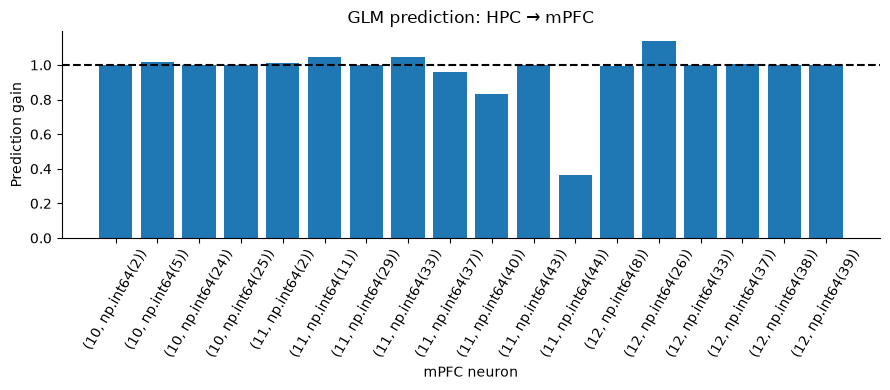

In [46]:
plt.figure(figsize=(9, 4))

x = np.arange(len(df_results_hpc))

plt.bar(
    x,
    df_results_hpc["gain"]
)

plt.axhline(
    1,
    linestyle="--",
    color="black"
)

plt.xticks(
    x,
    df_results_hpc["neuron_id"],
    rotation=60
)

plt.ylabel("Prediction gain")
plt.xlabel("mPFC neuron")
plt.title("GLM prediction: HPC → mPFC")

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [47]:
RE_groups = [1, 2, 3, 4]
re_files = []

for g in RE_groups:
    re_files.append({
        "group": g,
        "clu" : next(chemin.glob(f"*.clu.{g}")),
        "res" : next(chemin.glob(f"*.res.{g}"))
    })

In [48]:
re_units = load_units(re_files, FE)

re_units = {
    unit_id: spikes
    for unit_id, spikes in re_units.items()
    if unit_id[1] > 1
} 

print("Nombre d'unités RE:", len(re_units))

Nombre d'unités RE: 69


In [49]:
X_re, re_unit_ids = build_hpc_matrix(re_units, delta_peaks, window=0.200)

print("Shape X_re:", X_re.shape)

Shape X_re: (3338, 69)


In [50]:
keep_re = X_re.sum(axis=0) > 0

X_re = X_re[:, keep_re]

re_units_ids = [unit_id for unit_id, keep in zip(re_unit_ids, keep_re) if keep]

print("Nombre d'unités RE après filtrage:", len(re_units_ids))

Nombre d'unités RE après filtrage: 69


In [51]:
X_hpc_re = np.column_stack([X_hpc, X_re])

print("Shape X_hpc_re:", X_hpc_re.shape)

Shape X_hpc_re: (3338, 130)


In [52]:
results_hpc_re = {}
rows_hpc_re = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_hpc_re, y, n_shuffles=1000, random_state=42)
        results_hpc_re[unit_id] = result

        rows_hpc_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows_hpc_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_hpc_re = pd.DataFrame(rows_hpc_re)

print(df_results_hpc_re[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes
  Gain : 0.9140
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.0000
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9939
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0573
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0197
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0000
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes
  Gain : 1.0012
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0415
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.7361
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes
  Gain : 0.9911
Neurone 11/18 : (11, np.int64(43)) - 18 delta spikes
  Gain : 1.1027
Neurone 12/18 : (11, np.int64(44)) - 7 delta spikes
  Gain : 1.0051
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.6791
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes
  Gain : 0.9906
Neurone 15/18 : (12, np.int64(33)) - 2 delta spike

In [53]:
comparison = df_results_hpc[["neuron_id", "n_delta_spikes", "gain"]].copy()

comparison = comparison.rename(columns={"gain": "gain_hpc"})

comparison["gain_hpc_re"] = df_results_hpc_re["gain"].values

comparison["delta_gain"] = comparison["gain_hpc_re"] - comparison["gain_hpc"]

print(comparison[["neuron_id", "n_delta_spikes", "gain_hpc", "gain_hpc_re", "delta_gain"]].to_string(index=False))

neuron_id  n_delta_spikes  gain_hpc  gain_hpc_re  delta_gain
  (10, 2)               6  1.000000     0.914011   -0.085989
  (10, 5)              24  1.015301     1.000000   -0.015301
 (10, 24)             129  0.999442     0.993946   -0.005496
 (10, 25)              29  1.000000     1.057332    0.057332
  (11, 2)             270  1.012976     1.019691    0.006715
 (11, 11)              16  1.048578     1.000000   -0.048578
 (11, 29)               2  1.000000     1.001212    0.001212
 (11, 33)              75  1.045164     1.041481   -0.003683
 (11, 37)              14  0.960004     0.736056   -0.223948
 (11, 40)               3  0.833783     0.991146    0.157363
 (11, 43)              18  0.999579     1.102710    0.103131
 (11, 44)               7  0.364096     1.005095    0.640999
  (12, 8)              14  0.993625     0.679052   -0.314573
 (12, 26)               3  1.137527     0.990556   -0.146971
 (12, 33)               2  1.000000     1.002687    0.002687
 (12, 37)              9

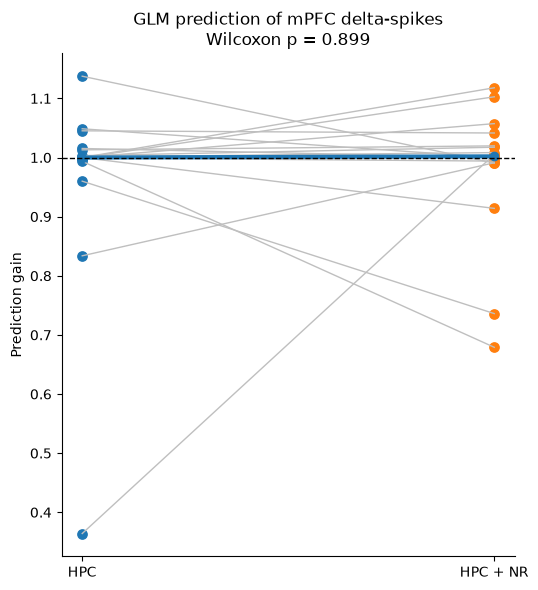

In [54]:
glm_hpc = comparison["gain_hpc"].values
glm_hpc_nr = comparison["gain_hpc_re"].values

stat, p_glm = wilcoxon(glm_hpc, glm_hpc_nr)

fig, ax = plt.subplots(figsize=(5.5, 6))

for i in range(len(glm_hpc)):
    ax.plot(
        [0, 1],
        [glm_hpc[i], glm_hpc_nr[i]],
        color="0.75",
        linewidth=1
    )

ax.scatter(
    np.zeros(len(glm_hpc)),
    glm_hpc,
    s=45
)

ax.scatter(
    np.ones(len(glm_hpc)),
    glm_hpc_nr,
    s=45
)

ax.plot(
    [0, 1],
    [np.median(glm_hpc), np.median(glm_hpc_nr)],
    linewidth=3,
    marker="o"
)

ax.axhline(
    1,
    linestyle="--",
    color="black",
    linewidth=1
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["HPC", "HPC + NR"])

ax.set_ylabel("Prediction gain")
ax.set_title(
    f"GLM prediction of mPFC delta-spikes\nWilcoxon p = {p_glm:.3f}"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

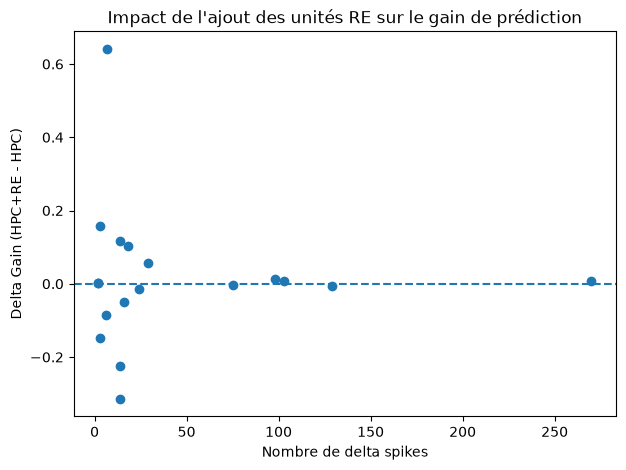

In [55]:
plt.figure(figsize=(7,5))

plt.scatter(comparison["n_delta_spikes"], comparison["delta_gain"])

plt.axhline(0, linestyle="--")

plt.xlabel("Nombre de delta spikes")
plt.ylabel("Delta Gain (HPC+RE - HPC)")
plt.title("Impact de l'ajout des unités RE sur le gain de prédiction")

plt.show()

In [56]:
results_re = {}
rows_re = []

for neuron_id in range (Y_mpfc.shape[1]):
    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    print(
        f"Neurone {neuron_id+1}/{Y_mpfc.shape[1]} :"
        f" {unit_id} - {int(y.sum())} delta spikes")

    try:
        result = compute_pred_gain(X_re, y, n_shuffles=1000, random_state=42)
        results_re[unit_id] = result

        rows_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : result["n_folds"],
            "e": result["e"],
            "e_shuffled": result["e_shuffled"],
            "gain": result["gain"],
            "n_not_converged": result["n_not_converged"]
        })

        print(f"  Gain : {result['gain']:.4f}")

    except Exception as error:
        print(f"Erreur pour le neurone {unit_id}: {error}")

        rows_re.append({
            "neuron_id" : unit_id,
            "n_delta_spikes" : int(y.sum()),
            "n_folds" : np.nan,
            "e": np.nan,
            "e_shuffled": np.nan,
            "gain": np.nan,
            "n_not_converged": np.nan
        })

df_results_re = pd.DataFrame(rows_re)

print(df_results_re[["neuron_id", "n_delta_spikes", "gain", "n_not_converged"]])

Neurone 1/18 : (10, np.int64(2)) - 6 delta spikes
  Gain : 0.7782
Neurone 2/18 : (10, np.int64(5)) - 24 delta spikes
  Gain : 1.1343
Neurone 3/18 : (10, np.int64(24)) - 129 delta spikes
  Gain : 0.9957
Neurone 4/18 : (10, np.int64(25)) - 29 delta spikes
  Gain : 1.0058
Neurone 5/18 : (11, np.int64(2)) - 270 delta spikes
  Gain : 1.0083
Neurone 6/18 : (11, np.int64(11)) - 16 delta spikes
  Gain : 1.0000
Neurone 7/18 : (11, np.int64(29)) - 2 delta spikes
  Gain : 1.0000
Neurone 8/18 : (11, np.int64(33)) - 75 delta spikes
  Gain : 1.0018
Neurone 9/18 : (11, np.int64(37)) - 14 delta spikes
  Gain : 0.9968
Neurone 10/18 : (11, np.int64(40)) - 3 delta spikes
  Gain : 0.9843
Neurone 11/18 : (11, np.int64(43)) - 18 delta spikes
  Gain : 1.1877
Neurone 12/18 : (11, np.int64(44)) - 7 delta spikes
  Gain : nan
Neurone 13/18 : (12, np.int64(8)) - 14 delta spikes
  Gain : 0.9763
Neurone 14/18 : (12, np.int64(26)) - 3 delta spikes
  Gain : 0.9814
Neurone 15/18 : (12, np.int64(33)) - 2 delta spikes
 

In [57]:
comparison_all = df_results_hpc[["neuron_id", "n_delta_spikes", "gain"]].copy()

comparison_all = comparison.rename(columns={"gain": "gain_hpc"})

comparison_all["gain_re"] = df_results_re["gain"].values

comparison_all["gain_hpc_re"] = df_results_hpc_re["gain"].values

comparison_all["delta_gain"] = comparison_all["gain_hpc_re"] - comparison_all["gain_hpc"]

print(comparison_all.to_string(index=False))

neuron_id  n_delta_spikes  gain_hpc  gain_hpc_re  delta_gain  gain_re
  (10, 2)               6  1.000000     0.914011   -0.085989 0.778196
  (10, 5)              24  1.015301     1.000000   -0.015301 1.134301
 (10, 24)             129  0.999442     0.993946   -0.005496 0.995679
 (10, 25)              29  1.000000     1.057332    0.057332 1.005812
  (11, 2)             270  1.012976     1.019691    0.006715 1.008297
 (11, 11)              16  1.048578     1.000000   -0.048578 1.000000
 (11, 29)               2  1.000000     1.001212    0.001212 1.000000
 (11, 33)              75  1.045164     1.041481   -0.003683 1.001823
 (11, 37)              14  0.960004     0.736056   -0.223948 0.996804
 (11, 40)               3  0.833783     0.991146    0.157363 0.984250
 (11, 43)              18  0.999579     1.102710    0.103131 1.187661
 (11, 44)               7  0.364096     1.005095    0.640999      NaN
  (12, 8)              14  0.993625     0.679052   -0.314573 0.976256
 (12, 26)           

In [58]:
def build_matrix_window(units, delta_peaks, start, end):
    
    unit_ids = list(units.keys())

    X = np.zeros(
        (len(delta_peaks), len(unit_ids)),
        dtype=int
    )

    for j, unit_id in enumerate(unit_ids):

        spikes = np.asarray(units[unit_id])

        left = np.searchsorted(
            spikes,
            delta_peaks + start,
            side="left"
        )

        right = np.searchsorted(
            spikes,
            delta_peaks + end,
            side="left"
        )

        X[:, j] = right - left

    return X, unit_ids

re_windows = [
    (-0.500, -0.300),
    (-0.400, -0.200),
    (-0.300, -0.100),
    (-0.200,  0.000),
    (-0.100,  0.100),
    ( 0.000,  0.200)
]

In [59]:
re_matrices = {}

for start, end in re_windows:

    X_re_window, re_ids_window = build_matrix_window(
        re_units,
        delta_peaks,
        start,
        end
    )

    keep = X_re_window.sum(axis=0) > 0

    X_re_window = X_re_window[:, keep]

    re_ids_window = [
        unit_id
        for unit_id, k in zip(re_ids_window, keep)
        if k
    ]

    key = (start, end)

    re_matrices[key] = {
        "X": X_re_window,
        "unit_ids": re_ids_window
    }

    print(
        f"Fenêtre {start*1000:.0f} à {end*1000:.0f} ms : "
        f"{X_re_window.shape[1]} unités RE"
    )

Fenêtre -500 à -300 ms : 69 unités RE
Fenêtre -400 à -200 ms : 69 unités RE
Fenêtre -300 à -100 ms : 69 unités RE
Fenêtre -200 à 0 ms : 69 unités RE
Fenêtre -100 à 100 ms : 69 unités RE
Fenêtre 0 à 200 ms : 69 unités RE


In [60]:
j = mpfc_units_ids.index((11, 2))

y = Y_mpfc[:, j]

folds_test = make_folds(
    y,
    random_state=42
)

print("Nombre de delta spikes :", y.sum())
print("Nombre de folds :", len(folds_test))

X_test_re = re_matrices[(-0.200, 0.000)]["X"]

print("Dimensions RE :", X_test_re.shape)

Nombre de delta spikes : 270
Nombre de folds : 270
Dimensions RE : (3338, 69)


In [61]:
result_test_re = compute_pred_gain(
    X_test_re,
    y,
    n_shuffles=1000,
    random_state=42,
    folds=folds_test
)

print("Gain RE :", result_test_re["gain"])
print("e :", result_test_re["e"])
print("e_shuffled :", result_test_re["e_shuffled"])
print("Folds non convergés :", result_test_re["n_not_converged"])

Gain RE : 1.0079602010293518
e : 0.07576740936273228
e_shuffled : 0.07637053317273282
Folds non convergés : 0


In [62]:
delay_results = []

for start, end in re_windows:

    X_re_window = re_matrices[(start, end)]["X"]

    print(
        f"\nFenêtre RE : {start*1000:.0f} à {end*1000:.0f} ms"
    )

    for neuron_id in range(Y_mpfc.shape[1]):

        unit_id = mpfc_units_ids[neuron_id]
        y = Y_mpfc[:, neuron_id]

        try:

            result = compute_pred_gain(
                X_re_window,
                y,
                n_shuffles=1000,
                random_state=42
            )

            delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_re": result["gain"],
                "n_not_converged": result["n_not_converged"]
            })

        except Exception as error:

            delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_re": np.nan,
                "n_not_converged": np.nan
            })


Fenêtre RE : -500 à -300 ms

Fenêtre RE : -400 à -200 ms

Fenêtre RE : -300 à -100 ms

Fenêtre RE : -200 à 0 ms

Fenêtre RE : -100 à 100 ms

Fenêtre RE : 0 à 200 ms


In [63]:
df_re_delays = pd.DataFrame(delay_results)

summary_re_delays = (
    df_re_delays
    .groupby(
        ["window_start_ms", "window_end_ms"]
    )["gain_re"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

summary_re_delays

,window_start_ms,window_end_ms,mean,median,count
0,-500,-300,0.989673,1.001166,18
1,-400,-200,1.034216,1.000000,18
2,-300,-100,0.972843,1.000000,18
3,-200,0,1.000200,1.000000,17
4,-100,100,0.990462,1.000000,18
5,0,200,0.996607,1.000000,17


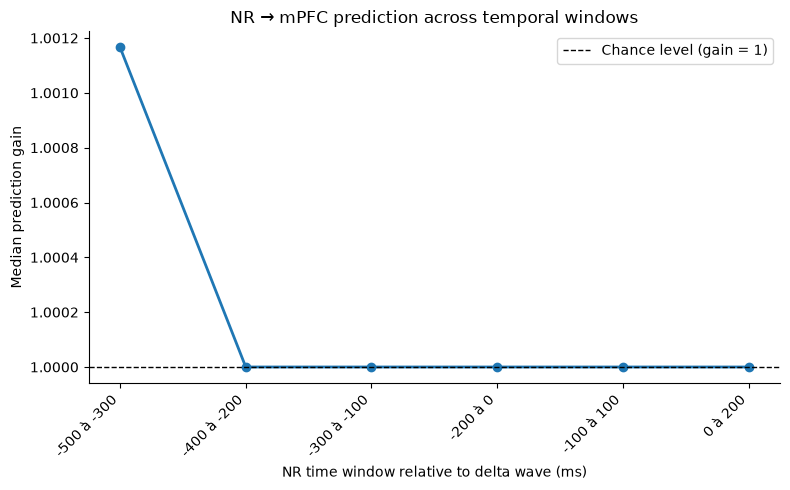

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = [
    f"{int(start)} à {int(end)}"
    for start, end in zip(
        summary_re_delays["window_start_ms"],
        summary_re_delays["window_end_ms"]
    )
]

x = np.arange(len(labels))

ax.plot(
    x,
    summary_re_delays["median"],
    marker="o",
    linewidth=2
)

ax.axhline(
    1,
    linestyle="--",
    color="black",
    linewidth=1,
    label="Chance level (gain = 1)"
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_xlabel("NR time window relative to delta wave (ms)")
ax.set_ylabel("Median prediction gain")
ax.set_title("NR → mPFC prediction across temporal windows")

ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [65]:
hpc_re_delay_results = []

for neuron_id in range(Y_mpfc.shape[1]):

    unit_id = mpfc_units_ids[neuron_id]
    y = Y_mpfc[:, neuron_id]

    # mêmes folds pour toutes les comparaisons de ce neurone
    folds_neuron = make_folds(
        y,
        random_state=42
    )

    print(
        f"\nNeurone {unit_id} "
        f"({int(y.sum())} delta spikes)"
    )

    for start, end in re_windows:

        X_re_window = re_matrices[(start, end)]["X"]

        # HPC fixe + RE à ce délai
        X_hpc_re_window = np.column_stack(
            (X_hpc, X_re_window)
        )

        print(
            f"  HPC + RE {start*1000:.0f} à {end*1000:.0f} ms"
        )

        try:

            result = compute_pred_gain(
                X_hpc_re_window,
                y,
                n_shuffles=1000,
                random_state=42,
                folds=folds_neuron
            )

            hpc_re_delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_hpc_re": result["gain"],
                "e": result["e"],
                "e_shuffled": result["e_shuffled"],
                "n_not_converged": result["n_not_converged"]
            })

        except Exception as error:

            print("    ERREUR :", error)

            hpc_re_delay_results.append({
                "neuron_id": unit_id,
                "n_delta_spikes": int(y.sum()),
                "window_start_ms": int(start * 1000),
                "window_end_ms": int(end * 1000),
                "gain_hpc_re": np.nan,
                "e": np.nan,
                "e_shuffled": np.nan,
                "n_not_converged": np.nan
            })


Neurone (10, np.int64(2)) (6 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (10, np.int64(5)) (24 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (10, np.int64(24)) (129 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (10, np.int64(25)) (29 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (11, np.int64(2)) (270 delta spikes)
  HPC + RE -500 à -300 ms
  HPC + RE -400 à -200 ms
  HPC + RE -300 à -100 ms
  HPC + RE -200 à 0 ms
  HPC + RE -100 à 100 ms
  HPC + RE 0 à 200 ms

Neurone (11, np.int64(11)) (16 

In [66]:
df_hpc_re_delays = pd.DataFrame(
    hpc_re_delay_results
)

df_hpc_re_delays.head()

,neuron_id,n_delta_spikes,window_start_ms,window_end_ms,gain_hpc_re,e,e_shuffled,n_not_converged
0,"(10, 2)",6,-500,-300,1.000000,1.766978e-31,1.766978e-31,0
1,"(10, 2)",6,-400,-200,1.016338,1.109162e-30,1.127283e-30,0
2,"(10, 2)",6,-300,-100,1.000000,1.029972e-33,1.029972e-33,0
3,"(10, 2)",6,-200,0,0.884485,3.653549e-33,3.231511e-33,0
4,"(10, 2)",6,-100,100,0.990214,2.290356e-32,2.267943e-32,0


In [67]:
print(df_results_hpc.columns)

Index(['neuron_id', 'n_delta_spikes', 'n_folds', 'e', 'e_shuffled', 'gain',
       'n_not_converged'],
      dtype='str')


In [68]:
comparison_delays = df_hpc_re_delays.merge(
    df_results_hpc[
        ["neuron_id", "gain"]
    ],
    on="neuron_id",
    how="left"
)

comparison_delays = comparison_delays.rename(
    columns={"gain": "gain_hpc"}
)

comparison_delays["delta_gain"] = (
    comparison_delays["gain_hpc_re"]
    - comparison_delays["gain_hpc"]
)

In [69]:
summary_hpc_re_delays = (
    comparison_delays
    .groupby(
        ["window_start_ms", "window_end_ms"]
    )["delta_gain"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

summary_hpc_re_delays

,window_start_ms,window_end_ms,mean,median,count
0,-500,-300,-0.034824,0.006199,18
1,-400,-200,0.016073,0.010979,18
2,-300,-100,0.059812,0.000000,18
3,-200,0,0.018691,0.005060,18
4,-100,100,0.073919,0.001678,18
5,0,200,0.066068,0.009201,18


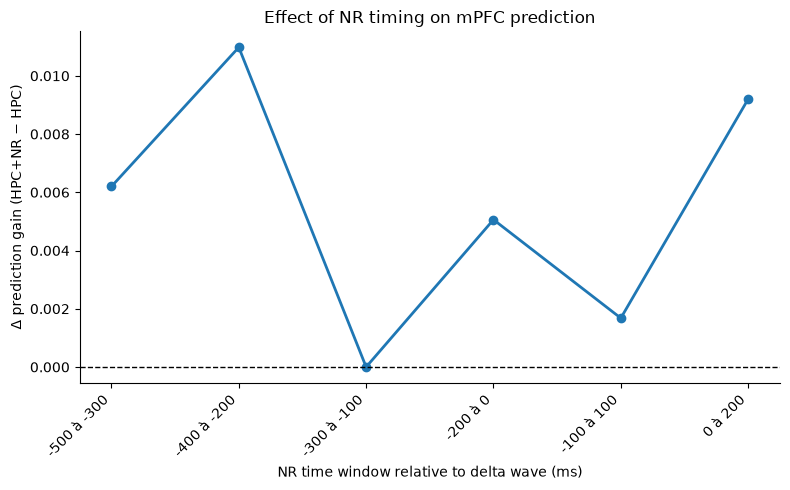

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = [
    f"{int(start)} à {int(end)}"
    for start, end in zip(
        summary_hpc_re_delays["window_start_ms"],
        summary_hpc_re_delays["window_end_ms"]
    )
]

x = np.arange(len(labels))

ax.plot(
    x,
    summary_hpc_re_delays["median"],
    marker="o",
    linewidth=2
)

ax.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_xlabel("NR time window relative to delta wave (ms)")
ax.set_ylabel("Δ prediction gain (HPC+NR − HPC)")
ax.set_title("Effect of NR timing on mPFC prediction")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [71]:
pivot_delta = comparison_delays.pivot(
    index=["neuron_id", "n_delta_spikes"],
    columns="window_start_ms",
    values="delta_gain"
)

pivot_delta.columns = [
    f"{int(x)} ms"
    for x in pivot_delta.columns
]

pivot_delta

,,-500 ms,-400 ms,-300 ms,-200 ms,-100 ms,0 ms
neuron_id,n_delta_spikes,,,,,,
"(10, 2)",6,0.000000,0.016338,0.000000,-0.115515,-0.009786,0.000000
"(10, 5)",24,-0.915331,-0.125182,-0.015301,-0.015301,-0.015301,-0.045073
"(10, 24)",129,0.009868,0.012756,-0.002172,-0.005906,0.003356,0.003668
"(10, 25)",29,-0.035013,-0.037736,-0.035816,0.046377,-0.021226,-0.020618
"(11, 2)",270,0.016771,0.019350,0.016636,0.006461,0.010509,0.014657
"(11, 11)",16,-0.096441,0.012972,0.003062,-0.048578,0.803700,0.673873
"(11, 29)",2,0.002530,0.000000,0.000000,0.005737,0.000000,0.000000
"(11, 33)",75,-0.023901,-0.008708,-0.019148,-0.006259,-0.003310,0.036527
"(11, 37)",14,0.039996,0.039996,0.122866,-0.317457,-0.304459,0.077659


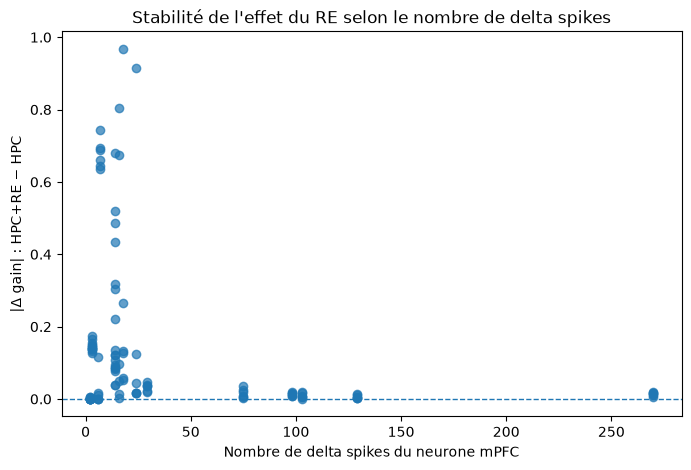

In [72]:
comparison_delays["abs_delta_gain"] = (
    comparison_delays["delta_gain"].abs()
)

plt.figure(figsize=(8, 5))

plt.scatter(
    comparison_delays["n_delta_spikes"],
    comparison_delays["abs_delta_gain"],
    alpha=0.7
)

plt.xlabel("Nombre de delta spikes du neurone mPFC")
plt.ylabel("|Δ gain| : HPC+RE − HPC")
plt.title("Stabilité de l'effet du RE selon le nombre de delta spikes")

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.show()

In [73]:
rho, p = spearmanr(
    comparison_delays["n_delta_spikes"],
    comparison_delays["abs_delta_gain"]
)

print("rho =", rho)
print("p =", p)

rho = -0.15220145089566015
p = 0.11583583505300138


In [74]:
stability_by_neuron = (
    comparison_delays
    .groupby(["neuron_id", "n_delta_spikes"])
    ["abs_delta_gain"]
    .mean()
    .reset_index()
)

rho_neuron, p_neuron = spearmanr(
    stability_by_neuron["n_delta_spikes"],
    stability_by_neuron["abs_delta_gain"]
)

print("rho par neurone =", rho_neuron)
print("p par neurone =", p_neuron)

rho par neurone = -0.1449282351274927
p par neurone = 0.5661173897912011


In [75]:
wilcoxon_results = []

for start, end in re_windows:

    temp = comparison_delays[
        (comparison_delays["window_start_ms"] == int(start * 1000)) &
        (comparison_delays["window_end_ms"] == int(end * 1000))
    ].dropna(
        subset=["gain_hpc", "gain_hpc_re"]
    )

    stat, p = wilcoxon(
        temp["gain_hpc_re"],
        temp["gain_hpc"]
    )

    wilcoxon_results.append({
        "window_start_ms": int(start * 1000),
        "window_end_ms": int(end * 1000),
        "n_neurons": len(temp),
        "median_delta_gain": temp["delta_gain"].median(),
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(wilcoxon_results)

df_wilcoxon

,window_start_ms,window_end_ms,n_neurons,median_delta_gain,p_value
0,-500,-300,18,0.006199,0.876722
1,-400,-200,18,0.010979,0.351979
2,-300,-100,18,0.000000,0.820280
3,-200,0,18,0.005060,0.932281
4,-100,100,18,0.001678,0.437967
5,0,200,18,0.009201,0.147660


In [76]:
print(deltawaves.keys())

for key in deltawaves.keys():
    x = np.asarray(deltawaves[key])
    print(
        key,
        "shape =", x.shape,
        "dtype =", x.dtype
    )

dict_keys(['timestamps', 'peaks', 'peakNormedPower', 'detectorName', 'troughValue', 'badIntervals'])
timestamps shape = (3338, 2) dtype = float64
peaks shape = (3338,) dtype = float64
peakNormedPower shape = (3338,) dtype = float64
detectorName shape = () dtype = <U61
troughValue shape = (3338,) dtype = float64
badIntervals shape = (0,) dtype = uint8


In [77]:
print(deltawaves["detectorName"])

channel 159 (+1), CleanLFP, FindDeltaWaves, peak-trough > 3.7


In [78]:
# Fenêtre : -500 à +500 ms
window = 0.500

# Bins de 10 ms
bin_size = 0.010

bins = np.arange(
    -window,
    window + bin_size,
    bin_size
)

all_relative_spikes = []

for unit_id, spikes in mpfc_units.items():

    spikes = np.asarray(spikes)

    for delta in delta_peaks:

        left = np.searchsorted(
            spikes,
            delta - window,
            side="left"
        )

        right = np.searchsorted(
            spikes,
            delta + window,
            side="right"
        )

        relative_spikes = spikes[left:right] - delta

        all_relative_spikes.extend(relative_spikes)

all_relative_spikes = np.asarray(all_relative_spikes)

print("Nombre total de spikes autour des delta waves :",
      len(all_relative_spikes))

Nombre total de spikes autour des delta waves : 148802


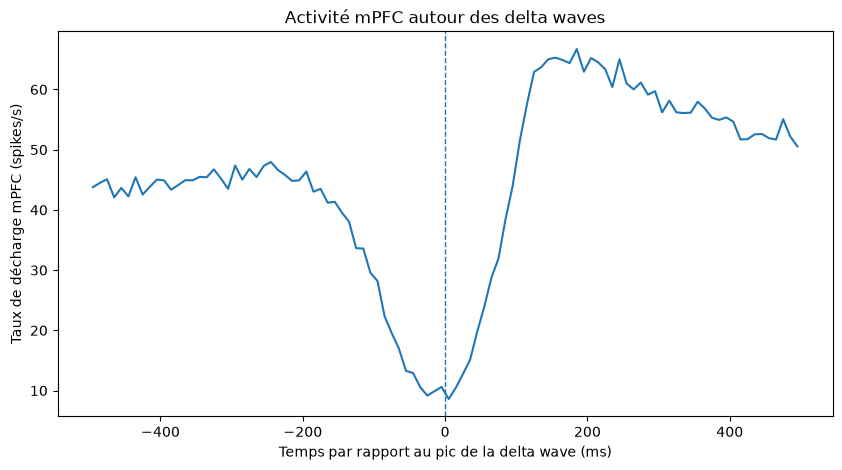

In [79]:
counts, edges = np.histogram(
    all_relative_spikes,
    bins=bins
)

# Nombre moyen de spikes par delta wave et par seconde
rate = counts / (len(delta_peaks) * bin_size)

centers = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(10, 5))

plt.plot(
    centers * 1000,
    rate
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Temps par rapport au pic de la delta wave (ms)")
plt.ylabel("Taux de décharge mPFC (spikes/s)")
plt.title("Activité mPFC autour des delta waves")

plt.show()

In [80]:
j = mpfc_units_ids.index((11, 2))

y = Y_mpfc[:, j]

print("Nombre total de delta waves :", len(y))
print("Nombre de delta spikes :", y.sum())
print("Nombre de non-delta spikes :", len(y) - y.sum())
print("Valeurs uniques dans y :", np.unique(y, return_counts=True))

Nombre total de delta waves : 3338
Nombre de delta spikes : 270
Nombre de non-delta spikes : 3068
Valeurs uniques dans y : (array([0, 1]), array([3068,  270]))


In [81]:
folds = make_folds(y, random_state=42)

print("Nombre de folds :", len(folds))

# Vérification de quelques folds
for i in range(5):
    train_idx, test_idx = folds[i]

    print(
        f"Fold {i+1} :",
        "test =", len(test_idx),
        "| positifs test =", y[test_idx].sum(),
        "| négatifs test =", len(test_idx) - y[test_idx].sum(),
        "| positifs train =", y[train_idx].sum()
    )

# Vérifie que chaque événement est testé exactement une fois
all_test_idx = np.concatenate(
    [test_idx for _, test_idx in folds]
)

print("\nÉvénements testés :", len(all_test_idx))
print("Événements uniques testés :", len(np.unique(all_test_idx)))

Nombre de folds : 270
Fold 1 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 2 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 3 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 4 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269
Fold 5 : test = 13 | positifs test = 1 | négatifs test = 12 | positifs train = 269

Événements testés : 3338
Événements uniques testés : 3338


In [82]:
predictions = np.full(len(y), np.nan)

for train_idx, test_idx in folds:

    X_train = X_hpc[train_idx]
    X_test = X_hpc[test_idx]

    y_train = y[train_idx]

    X_train_glm = sm.add_constant(
        X_train,
        has_constant="add"
    )

    X_test_glm = sm.add_constant(
        X_test,
        has_constant="add"
    )

    model = sm.GLM(
        y_train,
        X_train_glm,
        family=sm.families.Binomial()
    )

    results = model.fit()

    predictions[test_idx] = results.predict(
        X_test_glm
    )

print("NaN :", np.isnan(predictions).sum())

print("\nPrédictions pour y = 1")
print("moyenne :", predictions[y == 1].mean())
print("médiane :", np.median(predictions[y == 1]))

print("\nPrédictions pour y = 0")
print("moyenne :", predictions[y == 0].mean())
print("médiane :", np.median(predictions[y == 0]))

print("\nMin :", predictions.min())
print("Max :", predictions.max())

NaN : 0

Prédictions pour y = 1
moyenne : 0.10843143392702807
médiane : 0.08840082236526242

Prédictions pour y = 0
moyenne : 0.07878738184828117
médiane : 0.06847045345778874

Min : 0.00015460682586303324
Max : 0.5794746873796269


In [83]:
errors = np.abs(predictions - y)

errors_pos = errors[y == 1]
errors_neg = errors[y == 0]

print("ERREUR GLOBALE")
print("moyenne :", np.mean(errors))
print("médiane :", np.median(errors))

print("\nERREUR POUR y = 1")
print("moyenne :", np.mean(errors_pos))
print("médiane :", np.median(errors_pos))

print("\nERREUR POUR y = 0")
print("moyenne :", np.mean(errors_neg))
print("médiane :", np.median(errors_neg))

print("\nNombre y=1 :", len(errors_pos))
print("Nombre y=0 :", len(errors_neg))

ERREUR GLOBALE
moyenne : 0.1445306172409314
médiane : 0.07265513197786153

ERREUR POUR y = 1
moyenne : 0.8915685660729719
médiane : 0.9115991776347376

ERREUR POUR y = 0
moyenne : 0.07878738184828117
médiane : 0.06847045345778874

Nombre y=1 : 270
Nombre y=0 : 3068


In [84]:
unit_id = (11, 2)
spikes = np.asarray(mpfc_units[unit_id])

relative_spikes = []

for delta in delta_peaks:
    left = np.searchsorted(
        spikes,
        delta - 0.050,
        side="left"
    )
    right = np.searchsorted(
        spikes,
        delta + 0.050,
        side="right"
    )

    relative_spikes.extend(
        spikes[left:right] - delta
    )

relative_spikes = np.asarray(relative_spikes)

print("Nombre de spikes entre -50 et +50 ms :", len(relative_spikes))
print("Nombre dans ±15 ms :", np.sum(np.abs(relative_spikes) <= 0.015))

Nombre de spikes entre -50 et +50 ms : 1035
Nombre dans ±15 ms : 290


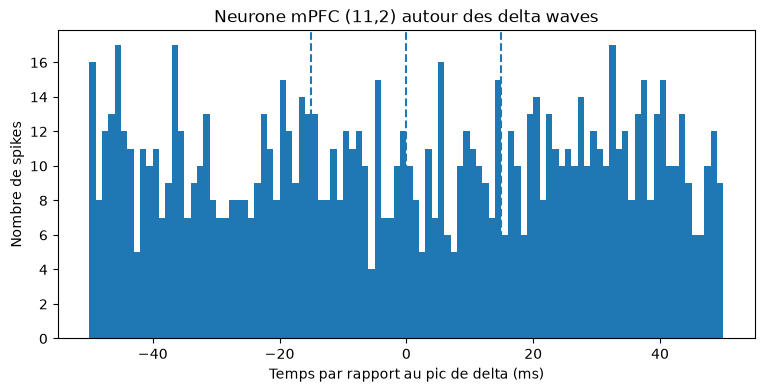

In [85]:
plt.figure(figsize=(9, 4))

plt.hist(
    relative_spikes * 1000,
    bins=np.arange(-50, 51, 1)
)

plt.axvline(-15, linestyle="--")
plt.axvline(0, linestyle="--")
plt.axvline(15, linestyle="--")

plt.xlabel("Temps par rapport au pic de delta (ms)")
plt.ylabel("Nombre de spikes")
plt.title("Neurone mPFC (11,2) autour des delta waves")

plt.show()

In [86]:
predictions_l2 = np.full(len(y), np.nan)

for train_idx, test_idx in folds:

    X_train = X_hpc[train_idx]
    X_test = X_hpc[test_idx]

    y_train = y[train_idx]

    # Normalisation apprise UNIQUEMENT sur le train
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Régression logistique avec régularisation L2
    model_l2 = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000
    )

    model_l2.fit(
        X_train_scaled,
        y_train
    )

    predictions_l2[test_idx] = model_l2.predict_proba(
        X_test_scaled
    )[:, 1]

print("NaN :", np.isnan(predictions_l2).sum())

print("\nPrédictions L2 pour y = 1")
print("moyenne :", predictions_l2[y == 1].mean())
print("médiane :", np.median(predictions_l2[y == 1]))

print("\nPrédictions L2 pour y = 0")
print("moyenne :", predictions_l2[y == 0].mean())
print("médiane :", np.median(predictions_l2[y == 0]))

print("\nMin :", predictions_l2.min())
print("Max :", predictions_l2.max())

NaN : 0

Prédictions L2 pour y = 1
moyenne : 0.10830510821910921
médiane : 0.0883832012745511

Prédictions L2 pour y = 0
moyenne : 0.07879025764670967
médiane : 0.06862027806633848

Min : 0.00019048551985340487
Max : 0.5778806096043424


In [87]:
errors_l2 = np.abs(
    predictions_l2 - y
)

e_l2 = np.median(errors_l2)

rng = np.random.default_rng(42)

shuffled_errors_l2 = []

for i in range(1000):

    shuffled_predictions = rng.permutation(
        predictions_l2
    )

    shuffled_error = np.median(
        np.abs(shuffled_predictions - y)
    )

    shuffled_errors_l2.append(
        shuffled_error
    )

e_shuffled_l2 = np.median(
    shuffled_errors_l2
)

g_l2 = e_shuffled_l2 / e_l2

print("e L2 =", e_l2)
print("e shuffled L2 =", e_shuffled_l2)
print("gain L2 =", g_l2)

print("\nRappel GLM Todorova :")
print("gain GLM ≈ 1.01298")

e L2 = 0.07284089328854929
e shuffled L2 = 0.0736374005761536
gain L2 = 1.010934891812063

Rappel GLM Todorova :
gain GLM ≈ 1.01298


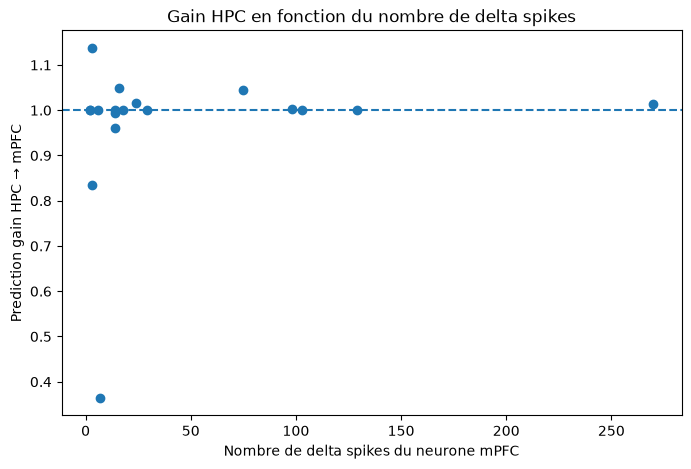

In [88]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_results_hpc["n_delta_spikes"],
    df_results_hpc["gain"]
)

plt.axhline(
    1,
    linestyle="--"
)

plt.xlabel("Nombre de delta spikes du neurone mPFC")
plt.ylabel("Prediction gain HPC → mPFC")
plt.title("Gain HPC en fonction du nombre de delta spikes")

plt.show()

In [89]:
rho, p = spearmanr(
    df_results_hpc["n_delta_spikes"],
    df_results_hpc["gain"]
)

print("Spearman rho =", rho)
print("p =", p)

Spearman rho = 0.2772040838648302
p = 0.2654303051766455


In [90]:
def build_hpc_sequence_exact(hpc_units, delta_peaks):

    unit_ids = list(hpc_units.keys())

    bin_edges = np.linspace(-0.200, 0.0, 21)

    bin_edges[0] = -0.200
    bin_edges[-1] = 0.0

    X_seq = np.zeros(
        (len(delta_peaks), len(unit_ids), 20),
        dtype=np.float32
    )

    for neuron_idx, unit_id in enumerate(unit_ids):

        spikes = np.asarray(hpc_units[unit_id])

        for bin_idx in range(20):

            # Pour chaque bin, m�mes r�gles :
            # [borne gauche, borne droite[
            left = np.searchsorted(
                spikes,
                delta_peaks + bin_edges[bin_idx],
                side="left"
            )

            right = np.searchsorted(
                spikes,
                delta_peaks + bin_edges[bin_idx + 1],
                side="left"
            )

            X_seq[:, neuron_idx, bin_idx] = (
                right - left
            )

    return X_seq, unit_ids, bin_edges

In [91]:
X_seq, hpc_seq_unit_ids, seq_edges = build_hpc_sequence_exact(
    hpc_units,
    delta_peaks
)

X_seq_sum = X_seq.sum(axis=2)

print("Shape X_seq :", X_seq.shape)

print(
    "Nombre de différences :",
    np.sum(X_seq_sum != X_hpc)
)

print(
    "Différence maximale :",
    np.max(np.abs(X_seq_sum - X_hpc))
)

Shape X_seq : (3338, 61, 20)
Nombre de différences : 13
Différence maximale : 1.0


In [92]:
j = mpfc_units_ids.index((11, 2))
y_cnn = Y_mpfc[:, j].astype(np.float32)

print("X_seq :", X_seq.shape)
print("y_cnn :", y_cnn.shape)
print("Positifs :", int(y_cnn.sum()))
print("Négatifs :", len(y_cnn) - int(y_cnn.sum()))

X_seq : (3338, 61, 20)
y_cnn : (3338,)
Positifs : 270
Négatifs : 3068


In [93]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X_seq,
    y_cnn,
    test_size=0.20,
    stratify=y_cnn,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=42
)

In [94]:
X_train_cnn = np.transpose(X_train, (0, 2, 1))
X_val_cnn = np.transpose(X_val, (0, 2, 1))
X_test_cnn = np.transpose(X_test, (0, 2, 1))

print("TRAIN :", X_train_cnn.shape)
print("VALIDATION :", X_val_cnn.shape)
print("TEST :", X_test_cnn.shape)

TRAIN : (2002, 20, 61)
VALIDATION : (668, 20, 61)
TEST : (668, 20, 61)


In [95]:
model_cnn = models.Sequential([
    layers.Input(shape=(20, 61)),

    layers.Conv1D(
        filters=16,
        kernel_size=3,
        activation="relu"
    ),

    layers.MaxPooling1D(pool_size=2),

    layers.Flatten(),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

model_cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc_roc"),
        tf.keras.metrics.AUC(curve="PR", name="auc_pr")
    ]
)

model_cnn.summary()

E0000 00:00:1789144838.048828 3840513 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 16)         │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281 (20.63 KB)

 Trainable params: 5,281 (20.63 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
early_stopping = EarlyStopping(
    monitor="val_auc_pr",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [97]:
history = model_cnn.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - auc_pr: 0.0766 - auc_roc: 0.4823 - loss: 0.4089 - val_auc_pr: 0.0867 - val_auc_roc: 0.5340 - val_loss: 0.3030
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - auc_pr: 0.0861 - auc_roc: 0.5339 - loss: 0.3056 - val_auc_pr: 0.0872 - val_auc_roc: 0.5399 - val_loss: 0.2914
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc_pr: 0.1128 - auc_roc: 0.5651 - loss: 0.2902 - val_auc_pr: 0.0873 - val_auc_roc: 0.5460 - val_loss: 0.2865
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc_pr: 0.1146 - auc_roc: 0.6037 - loss: 0.2789 - val_auc_pr: 0.0868 - val_auc_roc: 0.5461 - val_loss: 0.2830
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - auc_pr: 0.1334 - auc_roc: 0.6623 - loss: 0.2693 - val_auc_pr: 0.0864 - val_auc_roc: 0.5502 - val_loss: 0.2842
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - auc_pr: 0.1480 - auc_roc: 0.7013 - loss: 0.2623 - val_auc_pr: 0.0842 - val_auc_roc: 0.5387 - val_loss: 0.2829
Epoch 7/100
63/6

In [98]:
X_dev_cnn = np.concatenate(
    [X_train_cnn, X_val_cnn],
    axis=0
)

y_dev_cnn = np.concatenate(
    [y_train, y_val],
    axis=0
)

print("X_dev_cnn :", X_dev_cnn.shape)
print("y_dev_cnn :", y_dev_cnn.shape)
print("positifs :", int(y_dev_cnn.sum()))
print("négatifs :", len(y_dev_cnn) - int(y_dev_cnn.sum()))

X_dev_cnn : (2670, 20, 61)
y_dev_cnn : (2670,)
positifs : 216
négatifs : 2454


In [99]:
def build_cnn(
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.3,
    learning_rate=1e-3
):

    model = models.Sequential([
        layers.Input(shape=(20, 61)),

        layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            dense_units,
            activation="relu"
        ),

        layers.Dropout(dropout),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy"
    )

    return model

In [100]:
cnn_classifier = KerasClassifier(
    model=build_cnn,
    epochs=30,
    batch_size=32,
    verbose=0,
    random_state=42
)

In [101]:
def ap_scorer(estimator, X, y):
    proba = estimator.predict_proba(X)

    if proba.ndim == 2:
        proba = proba[:, 1]

    return average_precision_score(y, proba)

In [102]:
param_grid = {
    "model__filters": [8, 16, 32],
    "model__kernel_size": [2, 3, 5],
    "model__dense_units": [8, 16],
    "model__dropout": [0.2, 0.4],
    "model__learning_rate": [3e-4, 1e-3]
}

In [103]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [104]:
grid_search = GridSearchCV(
    estimator=cnn_classifier,
    param_grid=param_grid,
    scoring=ap_scorer,
    cv=cv,
    n_jobs=1,
    verbose=2
)

In [105]:
grid_search.fit(
    X_dev_cnn,
    y_dev_cnn
)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


E0000 00:00:1789144849.485382 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.4s


E0000 00:00:1789144871.805990 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789144895.024495 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.6s


E0000 00:00:1789144917.591705 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789144940.303450 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.9s


E0000 00:00:1789144963.254119 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  22.4s


E0000 00:00:1789144985.679447 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  22.4s


E0000 00:00:1789145008.134354 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  22.5s


E0000 00:00:1789145030.666418 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  21.9s


E0000 00:00:1789145052.574127 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.2s


E0000 00:00:1789145075.794188 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.1s


E0000 00:00:1789145097.918664 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  21.2s


E0000 00:00:1789145119.125739 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  21.9s


E0000 00:00:1789145141.045235 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.8s


E0000 00:00:1789145163.866499 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.5s


E0000 00:00:1789145186.410443 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  21.8s


E0000 00:00:1789145208.210978 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789145231.467099 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  21.7s


E0000 00:00:1789145253.205349 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  22.2s


E0000 00:00:1789145275.437123 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789145298.779404 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.8s


E0000 00:00:1789145320.547922 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.6s


E0000 00:00:1789145342.144230 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.6s


E0000 00:00:1789145363.788470 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.8s


E0000 00:00:1789145386.608688 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.0s


E0000 00:00:1789145409.652795 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  21.7s


E0000 00:00:1789145431.353380 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  21.8s


E0000 00:00:1789145453.185222 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.4s


E0000 00:00:1789145475.557846 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.5s


E0000 00:00:1789145498.043113 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  21.4s


E0000 00:00:1789145519.403492 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789145542.473572 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.9s


E0000 00:00:1789145565.332105 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.8s


E0000 00:00:1789145589.158045 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789145612.403573 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.8s


E0000 00:00:1789145635.240161 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.2s


E0000 00:00:1789145658.472665 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  22.8s


E0000 00:00:1789145681.231446 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  22.4s


E0000 00:00:1789145703.587484 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  22.1s


E0000 00:00:1789145725.648771 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  22.6s


E0000 00:00:1789145748.206433 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.4s


E0000 00:00:1789145770.650508 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.1s


E0000 00:00:1789145792.697682 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789145815.390806 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.0s


E0000 00:00:1789145837.430866 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.1s


E0000 00:00:1789145859.522064 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  22.7s


E0000 00:00:1789145882.186948 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  21.7s


E0000 00:00:1789145904.638329 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  22.3s


E0000 00:00:1789145926.196663 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  22.3s


E0000 00:00:1789145948.517984 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789145971.804513 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.3s


E0000 00:00:1789145993.115910 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.1s


E0000 00:00:1789146014.229892 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.5s


E0000 00:00:1789146038.704116 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.6s


E0000 00:00:1789146063.260126 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789146085.945983 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  21.5s


E0000 00:00:1789146107.461325 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  21.7s


E0000 00:00:1789146129.186660 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  21.1s


E0000 00:00:1789146150.240505 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  22.8s


E0000 00:00:1789146172.995937 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  21.7s


E0000 00:00:1789146194.671569 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.4s


E0000 00:00:1789146218.060192 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789146240.735764 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  25.7s


E0000 00:00:1789146266.456595 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.3s


E0000 00:00:1789146290.729889 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.0s


E0000 00:00:1789146314.709534 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  22.9s


E0000 00:00:1789146337.583856 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  23.0s


E0000 00:00:1789146360.543934 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  23.9s


E0000 00:00:1789146384.456190 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  22.5s


E0000 00:00:1789146406.943922 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  22.5s


E0000 00:00:1789146429.429646 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.9s


E0000 00:00:1789146452.375775 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789146475.661992 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789146498.737915 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.9s


E0000 00:00:1789146521.636449 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.4s


E0000 00:00:1789146544.085457 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  22.1s


E0000 00:00:1789146566.210694 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  25.4s


E0000 00:00:1789146591.614678 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  25.3s


E0000 00:00:1789146616.876461 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.4s


E0000 00:00:1789146641.300674 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.4s


E0000 00:00:1789146665.673168 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789146688.372244 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.5s


E0000 00:00:1789146711.910536 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789146734.613519 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.1s


E0000 00:00:1789146756.725135 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.7s


E0000 00:00:1789146780.449813 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.7s


E0000 00:00:1789146805.136147 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  22.7s


E0000 00:00:1789146827.836944 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  23.2s


E0000 00:00:1789146851.063198 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.3s


E0000 00:00:1789146875.344073 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  22.7s


E0000 00:00:1789146898.037304 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.5s


E0000 00:00:1789146921.535159 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789146944.730846 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.4s


E0000 00:00:1789146967.139541 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  21.6s


E0000 00:00:1789146988.784558 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  21.7s


E0000 00:00:1789147010.519784 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  21.5s


E0000 00:00:1789147032.055856 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  21.9s


E0000 00:00:1789147053.955481 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  21.5s


E0000 00:00:1789147075.431866 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.2s


E0000 00:00:1789147098.659708 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789147121.951013 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789147144.672974 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  21.6s


E0000 00:00:1789147166.268391 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.4s


E0000 00:00:1789147188.645902 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  21.3s


E0000 00:00:1789147209.905207 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789147232.652378 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  21.9s


E0000 00:00:1789147254.525304 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  22.7s


E0000 00:00:1789147277.210714 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  22.8s


E0000 00:00:1789147300.026809 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  21.9s


E0000 00:00:1789147321.900575 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  24.3s


E0000 00:00:1789147346.159362 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.8s


E0000 00:00:1789147367.951942 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.0s


E0000 00:00:1789147388.929614 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.6s


E0000 00:00:1789147410.570343 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  21.4s


E0000 00:00:1789147431.983848 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.9s


E0000 00:00:1789147454.860191 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  21.8s


E0000 00:00:1789147476.660170 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.5s


E0000 00:00:1789147499.175926 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  23.4s


E0000 00:00:1789147522.558119 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.5s


E0000 00:00:1789147545.103959 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.2s


E0000 00:00:1789147567.356065 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.4s


E0000 00:00:1789147590.762929 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.7s


E0000 00:00:1789147614.444925 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.4s


E0000 00:00:1789147637.798864 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.5s


E0000 00:00:1789147660.278627 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789147683.380938 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.4s


E0000 00:00:1789147706.743040 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.4s


E0000 00:00:1789147730.100804 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.0s


E0000 00:00:1789147753.079497 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789147776.418349 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.5s


E0000 00:00:1789147799.885260 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.6s


E0000 00:00:1789147822.489937 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.5s


E0000 00:00:1789147845.974299 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.0s


E0000 00:00:1789147869.013123 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.5s


E0000 00:00:1789147891.489710 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.3s


E0000 00:00:1789147913.774563 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  22.4s


E0000 00:00:1789147936.139762 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  22.9s


E0000 00:00:1789147959.014083 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  25.7s


E0000 00:00:1789147984.760986 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789148008.037757 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.6s


E0000 00:00:1789148031.672615 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789148054.384352 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789148077.120789 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.4s


E0000 00:00:1789148100.511446 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789148123.790929 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789148147.848990 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  22.8s


E0000 00:00:1789148170.646949 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  22.9s


E0000 00:00:1789148193.574437 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.0s


E0000 00:00:1789148216.584532 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.0s


E0000 00:00:1789148239.602207 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.8s


E0000 00:00:1789148263.392447 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  25.3s


E0000 00:00:1789148288.675006 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.3s


E0000 00:00:1789148312.982324 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.7s


E0000 00:00:1789148336.678466 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.4s


E0000 00:00:1789148360.061393 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.6s


E0000 00:00:1789148384.634000 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.2s


E0000 00:00:1789148408.857807 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.2s


E0000 00:00:1789148433.012784 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.7s


E0000 00:00:1789148457.694573 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  23.8s


E0000 00:00:1789148481.463844 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.5s


E0000 00:00:1789148505.934310 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.5s


E0000 00:00:1789148530.455523 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  25.1s


E0000 00:00:1789148555.578827 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  25.4s


E0000 00:00:1789148580.945733 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.2s


E0000 00:00:1789148605.191561 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.4s


E0000 00:00:1789148629.613964 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  25.1s


E0000 00:00:1789148654.707077 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  25.1s


E0000 00:00:1789148679.767854 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  23.5s


E0000 00:00:1789148703.258622 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789148726.902854 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789148750.622238 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  26.8s


E0000 00:00:1789148777.378855 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  25.0s


E0000 00:00:1789148802.408984 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.9s


E0000 00:00:1789148827.258270 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.4s


E0000 00:00:1789148851.683223 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.3s


E0000 00:00:1789148875.975376 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.3s


E0000 00:00:1789148900.318610 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.5s


E0000 00:00:1789148924.844529 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  23.9s


E0000 00:00:1789148948.772545 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.9s


E0000 00:00:1789148973.718448 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=8, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.0s


E0000 00:00:1789148997.709373 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789149020.913637 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789149043.998996 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789149066.701743 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789149089.760148 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789149112.913633 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.0s


E0000 00:00:1789149135.958384 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.1s


E0000 00:00:1789149159.099323 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.5s


E0000 00:00:1789149182.591980 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789149206.350555 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789149230.010010 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789149253.183743 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.5s


E0000 00:00:1789149275.667779 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789149298.930385 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.6s


E0000 00:00:1789149321.554212 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.0s


E0000 00:00:1789149344.523730 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  22.9s


E0000 00:00:1789149367.388967 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  24.0s


E0000 00:00:1789149391.349345 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  22.8s


E0000 00:00:1789149414.129659 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  22.4s


E0000 00:00:1789149436.541379 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  23.4s


E0000 00:00:1789149459.934034 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.6s


E0000 00:00:1789149482.524888 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.6s


E0000 00:00:1789149505.163775 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.5s


E0000 00:00:1789149527.670596 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789149550.401167 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789149573.061984 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.9s


E0000 00:00:1789149595.985518 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.5s


E0000 00:00:1789149618.472189 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  23.0s


E0000 00:00:1789149641.473837 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  23.2s


E0000 00:00:1789149664.661125 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  26.7s


E0000 00:00:1789149691.338450 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.3s


E0000 00:00:1789149715.673775 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.7s


E0000 00:00:1789149740.326147 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.5s


E0000 00:00:1789149763.854566 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.5s


E0000 00:00:1789149787.348566 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789149810.602023 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789149834.319026 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.9s


E0000 00:00:1789149858.209064 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789149881.497099 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  24.0s


E0000 00:00:1789149905.471814 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789149929.223036 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.4s


E0000 00:00:1789149953.646064 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789149976.871732 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.2s


E0000 00:00:1789150001.110161 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.0s


E0000 00:00:1789150024.160970 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789150048.239500 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  24.2s


E0000 00:00:1789150072.423772 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789150095.734151 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789150119.475928 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789150142.724158 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.5s


E0000 00:00:1789150166.258757 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.9s


E0000 00:00:1789150189.203690 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.7s


E0000 00:00:1789150211.881059 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.2s


E0000 00:00:1789150234.100464 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789150257.334581 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.6s


E0000 00:00:1789150280.949650 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.2s


E0000 00:00:1789150304.189197 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.6s


E0000 00:00:1789150327.833339 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789150351.503998 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789150375.193413 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  22.0s


E0000 00:00:1789150397.159589 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789150421.266113 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  25.1s


E0000 00:00:1789150446.417914 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  25.4s


E0000 00:00:1789150471.858140 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  25.5s


E0000 00:00:1789150497.332522 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.8s


E0000 00:00:1789150522.098441 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.9s


E0000 00:00:1789150546.987041 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.8s


E0000 00:00:1789150571.783878 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  23.8s


E0000 00:00:1789150595.531216 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.4s


E0000 00:00:1789150619.919716 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.1s


E0000 00:00:1789150644.003900 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  25.0s


E0000 00:00:1789150668.994047 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.8s


E0000 00:00:1789150693.764040 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  25.2s


E0000 00:00:1789150718.985870 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  25.4s


E0000 00:00:1789150744.343427 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.9s


E0000 00:00:1789150769.214460 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  28.8s


E0000 00:00:1789150798.078414 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  25.3s


E0000 00:00:1789150823.334531 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  25.7s


E0000 00:00:1789150849.017592 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.3s


E0000 00:00:1789150873.291199 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.9s


E0000 00:00:1789150898.233331 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789150922.294104 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  25.4s


E0000 00:00:1789150947.691681 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.6s


E0000 00:00:1789150972.293103 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.5s


E0000 00:00:1789150996.774523 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.9s


E0000 00:00:1789151020.716104 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.6s


E0000 00:00:1789151045.280483 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  25.0s


E0000 00:00:1789151070.250660 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.3s


E0000 00:00:1789151094.519224 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  25.6s


E0000 00:00:1789151120.083805 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.2, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.6s


E0000 00:00:1789151144.709431 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.6s


E0000 00:00:1789151168.334949 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.9s


E0000 00:00:1789151192.259370 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.2s


E0000 00:00:1789151214.490016 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789151237.825663 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789151261.165363 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789151284.428317 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  22.1s


E0000 00:00:1789151306.543859 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.0s


E0000 00:00:1789151329.502374 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.1s


E0000 00:00:1789151352.580457 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=2, model__learning_rate=0.001; total time=  23.3s


E0000 00:00:1789151375.860928 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789151398.976499 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.4s


E0000 00:00:1789151422.347091 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.7s


E0000 00:00:1789151446.014145 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.9s


E0000 00:00:1789151469.897223 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789151492.962235 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  23.5s


E0000 00:00:1789151516.457071 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789151540.145069 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  23.6s


E0000 00:00:1789151563.784173 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  24.0s


E0000 00:00:1789151587.797493 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=3, model__learning_rate=0.001; total time=  23.1s


E0000 00:00:1789151610.936046 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789151634.035244 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789151658.131245 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.3s


E0000 00:00:1789151681.391929 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  22.9s


E0000 00:00:1789151704.299656 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.0s


E0000 00:00:1789151728.322073 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  24.3s


E0000 00:00:1789151752.663096 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  23.9s


E0000 00:00:1789151776.615846 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  22.0s


E0000 00:00:1789151798.626304 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789151822.346828 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=8, model__kernel_size=5, model__learning_rate=0.001; total time=  24.1s


E0000 00:00:1789151846.450683 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.8s


E0000 00:00:1789151869.294751 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.2s


E0000 00:00:1789151892.537881 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  22.5s


E0000 00:00:1789151915.052085 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.8s


E0000 00:00:1789151938.829318 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.0003; total time=  23.1s


E0000 00:00:1789151961.978437 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  22.7s


E0000 00:00:1789151984.660868 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.5s


E0000 00:00:1789152008.110210 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  21.6s


E0000 00:00:1789152029.762909 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  23.4s


E0000 00:00:1789152053.138763 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=2, model__learning_rate=0.001; total time=  29.4s


E0000 00:00:1789152082.506361 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789152106.622886 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.2s


E0000 00:00:1789152130.793087 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.5s


E0000 00:00:1789152155.336789 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  22.4s


E0000 00:00:1789152177.754914 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.0003; total time=  23.8s


E0000 00:00:1789152201.601345 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  24.1s


E0000 00:00:1789152225.663651 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.6s


E0000 00:00:1789152249.270649 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  24.5s


E0000 00:00:1789152273.748762 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  23.7s


E0000 00:00:1789152297.422806 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=3, model__learning_rate=0.001; total time=  25.0s


E0000 00:00:1789152322.454577 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789152346.623024 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.4s


E0000 00:00:1789152370.015389 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.0s


E0000 00:00:1789152393.063965 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.5s


E0000 00:00:1789152417.549713 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789152441.696347 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  23.6s


E0000 00:00:1789152465.270391 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  24.1s


E0000 00:00:1789152489.338362 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  24.1s


E0000 00:00:1789152513.431905 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  24.7s


E0000 00:00:1789152538.151636 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=16, model__kernel_size=5, model__learning_rate=0.001; total time=  22.0s


E0000 00:00:1789152560.137600 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.8s


E0000 00:00:1789152584.983565 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.2s


E0000 00:00:1789152609.154744 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  25.8s


E0000 00:00:1789152634.987246 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  25.1s


E0000 00:00:1789152660.075039 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.0003; total time=  24.8s


E0000 00:00:1789152684.894333 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.4s


E0000 00:00:1789152709.276838 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.7s


E0000 00:00:1789152733.928330 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  25.0s


E0000 00:00:1789152758.954975 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.6s


E0000 00:00:1789152783.532078 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=2, model__learning_rate=0.001; total time=  24.2s


E0000 00:00:1789152807.684251 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.2s


E0000 00:00:1789152831.903605 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.8s


E0000 00:00:1789152856.754141 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.1s


E0000 00:00:1789152880.835902 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  24.9s


E0000 00:00:1789152905.745469 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.0003; total time=  25.2s


E0000 00:00:1789152930.933204 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.9s


E0000 00:00:1789152955.882041 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.0s


E0000 00:00:1789152979.899384 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  25.9s


E0000 00:00:1789153005.823505 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.6s


E0000 00:00:1789153030.414109 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=3, model__learning_rate=0.001; total time=  24.5s


E0000 00:00:1789153054.945124 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.7s


E0000 00:00:1789153078.669652 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.8s


E0000 00:00:1789153102.516106 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.2s


E0000 00:00:1789153126.692128 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  23.8s


E0000 00:00:1789153150.521633 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.0003; total time=  24.3s


E0000 00:00:1789153174.808002 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.5s


E0000 00:00:1789153199.262630 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.3s


E0000 00:00:1789153223.520951 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.6s


E0000 00:00:1789153248.124989 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  25.2s


E0000 00:00:1789153273.332460 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


[CV] END model__dense_units=16, model__dropout=0.4, model__filters=32, model__kernel_size=5, model__learning_rate=0.001; total time=  24.9s


E0000 00:00:1789153298.220074 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KerasClassifi..._weight=None )
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__dense_units': [8, 16], 'model__dropout': [0.2, 0.4], 'model__filters': [8, 16, ...], 'model__kernel_size': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function ap_...x7f330d6c7920>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know mor

In [106]:
print("Meilleur score :", grid_search.best_score_)
print("Meilleurs paramètres :", grid_search.best_params_)

Meilleur score : 0.15054564682145816
Meilleurs paramètres : {'model__dense_units': 8, 'model__dropout': 0.2, 'model__filters': 32, 'model__kernel_size': 5, 'model__learning_rate': 0.0003}


In [107]:
def build_cnn2(
    filters=16,
    kernel_size=3,
    dense_units=16,
    dropout=0.3,
    learning_rate=0.0003,
    n_conv=1,
    n_dense=1
):

    model = models.Sequential()

    model.add(layers.Input(shape=(20, 61)))

    # Couches Conv1D
    for _ in range(n_conv):
        model.add(
            layers.Conv1D(
                filters=filters,
                kernel_size=kernel_size,
                activation="relu"
            )
        )

    model.add(layers.MaxPooling1D(pool_size=2))
    model.add(layers.Flatten())

    # Couches Dense
    for _ in range(n_dense):
        model.add(
            layers.Dense(
                dense_units,
                activation="relu"
            )
        )

    model.add(layers.Dropout(dropout))

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy"
    )

    return model

In [108]:
cnn_classifier = KerasClassifier(
    model=build_cnn2,
    epochs=30,
    batch_size=32,
    verbose=0,
    random_state=42
)

grid_layers = GridSearchCV(
    cnn_classifier,
    {
        "model__n_conv": [1, 2, 3, 4, 5],
        "model__n_dense": [0, 1, 2, 3, 4]
    },
    scoring=ap_scorer,
    cv=cv,
    n_jobs=1
)

grid_layers.fit(X_dev_cnn, y_dev_cnn)

print(grid_layers.best_score_)
print(grid_layers.best_params_)

E0000 00:00:1789153327.633746 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1789153351.219832 3840513 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),

0.138147662213161
{'model__n_conv': 3, 'model__n_dense': 0}


In [109]:
X_cnn = np.transpose(X_seq, (0, 2, 1))


def build_best_cnn():

    model = models.Sequential([
        layers.Input(shape=(20, 61)),

        layers.Conv1D(
            filters=32,
            kernel_size=5,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(
            8,
            activation="relu"
        ),

        layers.Dropout(0.2),

        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0003
        ),
        loss="binary_crossentropy"
    )

    return model


results = []


for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j]

    n_positive = int(y.sum())

    # Maximum 5 folds
    n_folds = min(5, n_positive)

    scores = []

    print(f"\n{unit_id} - {n_positive} delta-spikes")


    cv_neuron = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42
    )


    for train_idx, val_idx in cv_neuron.split(X_cnn, y):

        tf.keras.backend.clear_session()

        model = build_best_cnn()

        model.fit(
            X_cnn[train_idx],
            y[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn[val_idx],
            verbose=0
        ).ravel()

        score = average_precision_score(
            y[val_idx],
            pred
        )

        scores.append(score)


    results.append({
        "unit_id": unit_id,
        "n_delta_spikes": n_positive,
        "baseline_AP": n_positive / len(y),
        "mean_AP": np.mean(scores),
        "std_AP": np.std(scores)
    })

    print("AP moyenne :", round(np.mean(scores), 3))


df_cnn = pd.DataFrame(results)

df_cnn


(10, np.int64(2)) - 6 delta-spikes
AP moyenne : 0.004

(10, np.int64(5)) - 24 delta-spikes
AP moyenne : 0.019

(10, np.int64(24)) - 129 delta-spikes
AP moyenne : 0.047

(10, np.int64(25)) - 29 delta-spikes
AP moyenne : 0.013

(11, np.int64(2)) - 270 delta-spikes
AP moyenne : 0.119

(11, np.int64(11)) - 16 delta-spikes
AP moyenne : 0.015

(11, np.int64(29)) - 2 delta-spikes
AP moyenne : 0.002

(11, np.int64(33)) - 75 delta-spikes
AP moyenne : 0.051

(11, np.int64(37)) - 14 delta-spikes
AP moyenne : 0.006

(11, np.int64(40)) - 3 delta-spikes
AP moyenne : 0.003

(11, np.int64(43)) - 18 delta-spikes
AP moyenne : 0.031

(11, np.int64(44)) - 7 delta-spikes
AP moyenne : 0.02

(12, np.int64(8)) - 14 delta-spikes
AP moyenne : 0.009

(12, np.int64(26)) - 3 delta-spikes
AP moyenne : 0.008

(12, np.int64(33)) - 2 delta-spikes
AP moyenne : 0.003

(12, np.int64(37)) - 98 delta-spikes
AP moyenne : 0.036

(12, np.int64(38)) - 103 delta-spikes
AP moyenne : 0.062

(12, np.int64(39)) - 14 delta-spikes
A

,unit_id,n_delta_spikes,baseline_AP,mean_AP,std_AP
0,"(10, 2)",6,0.001797,0.004499,0.002924
1,"(10, 5)",24,0.007190,0.018985,0.010283
2,"(10, 24)",129,0.038646,0.047331,0.006042
3,"(10, 25)",29,0.008688,0.012724,0.006724
4,"(11, 2)",270,0.080887,0.119078,0.010333
5,"(11, 11)",16,0.004793,0.014695,0.006929
6,"(11, 29)",2,0.000599,0.001826,0.000578
7,"(11, 33)",75,0.022469,0.051484,0.024750
8,"(11, 37)",14,0.004194,0.006467,0.002414
9,"(11, 40)",3,0.000899,0.003107,0.002071


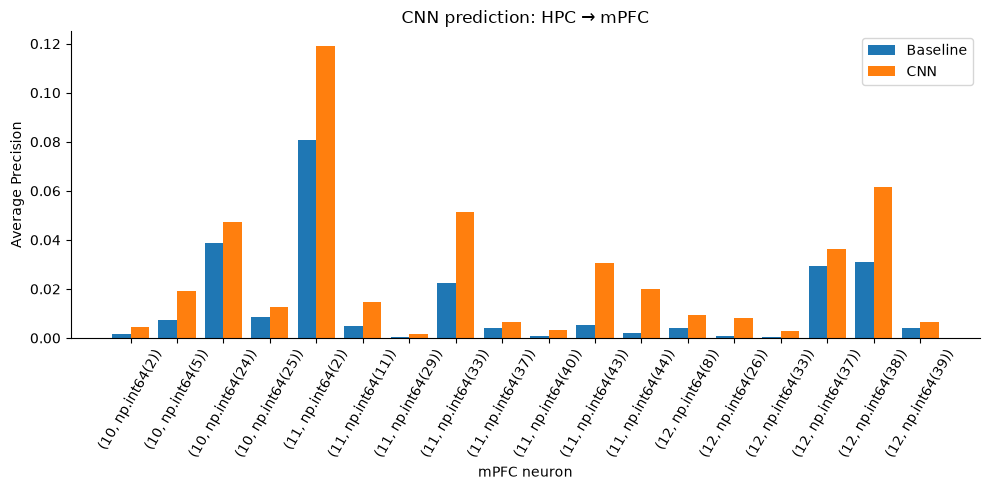

In [110]:
x = np.arange(len(df_cnn))

plt.figure(figsize=(10, 5))

plt.bar(
    x - 0.2,
    df_cnn["baseline_AP"],
    width=0.4,
    label="Baseline"
)

plt.bar(
    x + 0.2,
    df_cnn["mean_AP"],
    width=0.4,
    label="CNN"
)

plt.xticks(
    x,
    df_cnn["unit_id"],
    rotation=60
)

plt.ylabel("Average Precision")
plt.xlabel("mPFC neuron")
plt.title("CNN prediction: HPC → mPFC")

plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [111]:
n_shuffles = 100

shuffle_results = []

for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j].copy()
    real_ap = df_cnn.loc[j, "mean_AP"]

    shuffled_AP = []

    print(f"\n{unit_id}")

    for s in range(n_shuffles):

        # Mélange des labels
        rng = np.random.default_rng(s)
        y_shuffle = rng.permutation(y)

        # Un split stratifié
        train_idx, val_idx = next(
            StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=s
            ).split(X_cnn, y_shuffle)
        )

        tf.keras.backend.clear_session()

        model = build_best_cnn()

        model.fit(
            X_cnn[train_idx],
            y_shuffle[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn[val_idx],
            verbose=0
        ).ravel()

        ap = average_precision_score(
            y_shuffle[val_idx],
            pred
        )

        shuffled_AP.append(ap)

    # p-value empirique
    p_value = (
        np.sum(np.array(shuffled_AP) >= real_ap) + 1
    ) / (n_shuffles + 1)

    shuffle_results.append({
        "unit_id": unit_id,
        "real_AP": real_ap,
        "shuffle_AP": np.mean(shuffled_AP),
        "shuffle_std": np.std(shuffled_AP),
        "p_value": p_value
    })

    print(
        "réel =", round(real_ap, 4),
        "| shuffle =", round(np.mean(shuffled_AP), 4),
        "| p =", round(p_value, 4)
    )


df_shuffle = pd.DataFrame(shuffle_results)

df_shuffle


(10, np.int64(2))
réel = 0.0045 | shuffle = 0.0062 | p = 0.297

(10, np.int64(5))
réel = 0.019 | shuffle = 0.0133 | p = 0.1782

(10, np.int64(24))
réel = 0.0473 | shuffle = 0.0473 | p = 0.3762

(10, np.int64(25))
réel = 0.0127 | shuffle = 0.0195 | p = 0.6139

(11, np.int64(2))
réel = 0.1191 | shuffle = 0.0882 | p = 0.0297

(11, np.int64(11))
réel = 0.0147 | shuffle = 0.011 | p = 0.1485

(11, np.int64(29))
réel = 0.0018 | shuffle = 0.0 | p = 0.0099

(11, np.int64(33))
réel = 0.0515 | shuffle = 0.0323 | p = 0.099

(11, np.int64(37))
réel = 0.0065 | shuffle = 0.0102 | p = 0.4554

(11, np.int64(40))
réel = 0.0031 | shuffle = 0.0087 | p = 0.4554

(11, np.int64(43))
réel = 0.0306 | shuffle = 0.0121 | p = 0.0792

(11, np.int64(44))
réel = 0.02 | shuffle = 0.0151 | p = 0.0495

(12, np.int64(8))
réel = 0.0094 | shuffle = 0.0109 | p = 0.3762

(12, np.int64(26))
réel = 0.0081 | shuffle = 0.0061 | p = 0.1782

(12, np.int64(33))
réel = 0.0028 | shuffle = 0.0 | p = 0.0099

(12, np.int64(37))
réel =

,unit_id,real_AP,shuffle_AP,shuffle_std,p_value
0,"(10, 2)",0.004499,0.006243,0.014168,0.297030
1,"(10, 5)",0.018985,0.013303,0.007938,0.178218
2,"(10, 24)",0.047331,0.047270,0.011978,0.376238
3,"(10, 25)",0.012724,0.019529,0.021111,0.613861
4,"(11, 2)",0.119078,0.088165,0.012827,0.029703
5,"(11, 11)",0.014695,0.010995,0.011672,0.148515
6,"(11, 29)",0.001826,0.000000,0.000000,0.009901
7,"(11, 33)",0.051484,0.032268,0.016968,0.099010
8,"(11, 37)",0.006467,0.010192,0.009873,0.455446
9,"(11, 40)",0.003107,0.008687,0.021144,0.455446


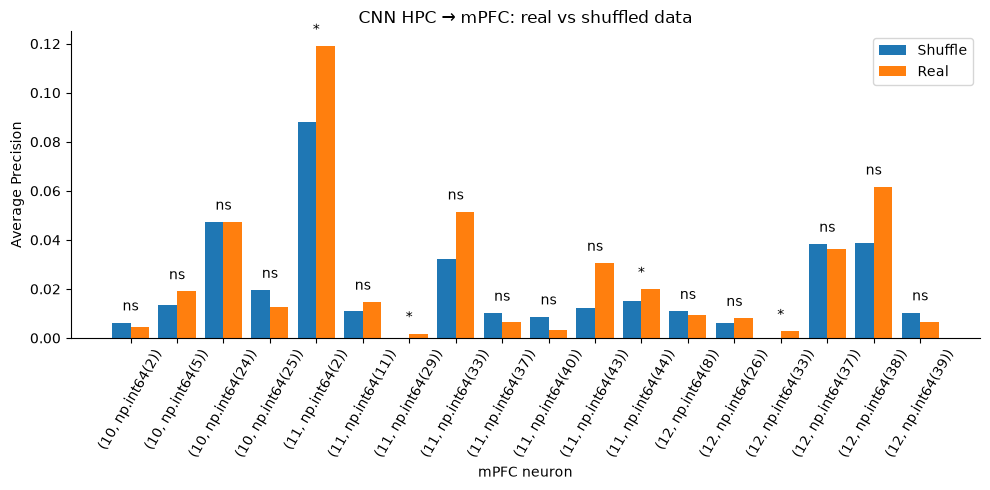

In [112]:
x = np.arange(len(df_shuffle))

plt.figure(figsize=(10, 5))

plt.bar(
    x - 0.2,
    df_shuffle["shuffle_AP"],
    width=0.4,
    label="Shuffle"
)

plt.bar(
    x + 0.2,
    df_shuffle["real_AP"],
    width=0.4,
    label="Real"
)

for i, row in df_shuffle.iterrows():

    y = max(row["real_AP"], row["shuffle_AP"])

    if row["p_value"] < 0.05:
        label = "*"
    else:
        label = "ns"

    plt.text(
        i,
        y + 0.005,
        label,
        ha="center"
    )

plt.xticks(
    x,
    df_shuffle["unit_id"],
    rotation=60
)

plt.ylabel("Average Precision")
plt.xlabel("mPFC neuron")
plt.title("CNN HPC → mPFC: real vs shuffled data")

plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [113]:
bin_edges = np.linspace(-0.200, 0, 21)

re_unit_ids = list(re_units.keys())

X_seq_nr = np.zeros(
    (len(delta_peaks), len(re_unit_ids), 20),
    dtype=np.float32
)

for j, unit_id in enumerate(re_unit_ids):

    spikes = np.asarray(re_units[unit_id])

    for i, delta in enumerate(delta_peaks):

        counts, _ = np.histogram(
            spikes,
            bins=delta + bin_edges
        )

        X_seq_nr[i, j, :] = counts


print("HPC :", X_seq.shape)
print("NR  :", X_seq_nr.shape)

HPC : (3338, 61, 20)
NR  : (3338, 69, 20)


In [114]:
X_seq_hpc_nr = np.concatenate(
    [X_seq, X_seq_nr],
    axis=1
)

X_cnn_hpc_nr = np.transpose(
    X_seq_hpc_nr,
    (0, 2, 1)
)

print("HPC + NR :", X_cnn_hpc_nr.shape)

HPC + NR : (3338, 20, 130)


In [115]:
def build_cnn_hpc_nr():

    model = models.Sequential([
        layers.Input(shape=(20, X_cnn_hpc_nr.shape[2])),

        layers.Conv1D(
            filters=32,
            kernel_size=5,
            activation="relu"
        ),

        layers.MaxPooling1D(pool_size=2),

        layers.Flatten(),

        layers.Dense(8, activation="relu"),

        layers.Dropout(0.2),

        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0003
        ),
        loss="binary_crossentropy"
    )

    return model

In [116]:
results_hpc_nr = []

for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j]
    n_positive = int(y.sum())
    n_folds = min(5, n_positive)

    scores = []

    print(f"\n{unit_id} - {n_positive} delta-spikes")

    cv_neuron = StratifiedKFold(
        n_splits=n_folds,
        shuffle=True,
        random_state=42
    )

    for train_idx, val_idx in cv_neuron.split(X_cnn_hpc_nr, y):

        tf.keras.backend.clear_session()

        model = build_cnn_hpc_nr()

        model.fit(
            X_cnn_hpc_nr[train_idx],
            y[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn_hpc_nr[val_idx],
            verbose=0
        ).ravel()

        scores.append(
            average_precision_score(
                y[val_idx],
                pred
            )
        )

    results_hpc_nr.append({
        "unit_id": unit_id,
        "n_delta_spikes": n_positive,
        "baseline_AP": n_positive / len(y),
        "mean_AP": np.mean(scores),
        "std_AP": np.std(scores)
    })

    print("AP moyenne :", round(np.mean(scores), 3))


df_cnn_hpc_nr = pd.DataFrame(results_hpc_nr)

df_cnn_hpc_nr


(10, np.int64(2)) - 6 delta-spikes
AP moyenne : 0.003

(10, np.int64(5)) - 24 delta-spikes
AP moyenne : 0.021

(10, np.int64(24)) - 129 delta-spikes
AP moyenne : 0.048

(10, np.int64(25)) - 29 delta-spikes
AP moyenne : 0.01

(11, np.int64(2)) - 270 delta-spikes
AP moyenne : 0.12

(11, np.int64(11)) - 16 delta-spikes
AP moyenne : 0.023

(11, np.int64(29)) - 2 delta-spikes
AP moyenne : 0.001

(11, np.int64(33)) - 75 delta-spikes
AP moyenne : 0.066

(11, np.int64(37)) - 14 delta-spikes
AP moyenne : 0.009

(11, np.int64(40)) - 3 delta-spikes
AP moyenne : 0.004

(11, np.int64(43)) - 18 delta-spikes
AP moyenne : 0.041

(11, np.int64(44)) - 7 delta-spikes
AP moyenne : 0.016

(12, np.int64(8)) - 14 delta-spikes
AP moyenne : 0.006

(12, np.int64(26)) - 3 delta-spikes
AP moyenne : 0.002

(12, np.int64(33)) - 2 delta-spikes
AP moyenne : 0.001

(12, np.int64(37)) - 98 delta-spikes
AP moyenne : 0.041

(12, np.int64(38)) - 103 delta-spikes
AP moyenne : 0.04

(12, np.int64(39)) - 14 delta-spikes
AP 

,unit_id,n_delta_spikes,baseline_AP,mean_AP,std_AP
0,"(10, 2)",6,0.001797,0.003266,0.000980
1,"(10, 5)",24,0.007190,0.020961,0.022520
2,"(10, 24)",129,0.038646,0.048053,0.021618
3,"(10, 25)",29,0.008688,0.009732,0.003354
4,"(11, 2)",270,0.080887,0.120172,0.033589
5,"(11, 11)",16,0.004793,0.023059,0.024230
6,"(11, 29)",2,0.000599,0.001342,0.000447
7,"(11, 33)",75,0.022469,0.066077,0.039316
8,"(11, 37)",14,0.004194,0.008993,0.007186
9,"(11, 40)",3,0.000899,0.004405,0.003842


HPC moyen      : 0.025307696292716425
HPC + NR moyen : 0.025387760927940768
p = 0.932281494140625


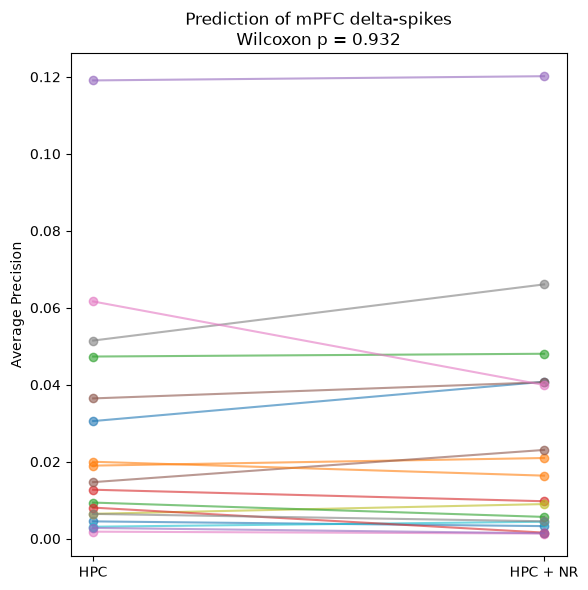

In [117]:
hpc = df_cnn["mean_AP"].values
hpc_nr = df_cnn_hpc_nr["mean_AP"].values

stat, p = wilcoxon(hpc, hpc_nr)

print("HPC moyen      :", np.mean(hpc))
print("HPC + NR moyen :", np.mean(hpc_nr))
print("p =", p)

plt.figure(figsize=(6, 6))

for i in range(len(hpc)):
    plt.plot(
        [0, 1],
        [hpc[i], hpc_nr[i]],
        marker="o",
        alpha=0.6
    )

plt.xticks(
    [0, 1],
    ["HPC", "HPC + NR"]
)

plt.ylabel("Average Precision")
plt.title(
    f"Prediction of mPFC delta-spikes\nWilcoxon p = {p:.3f}"
)

plt.tight_layout()
plt.show()

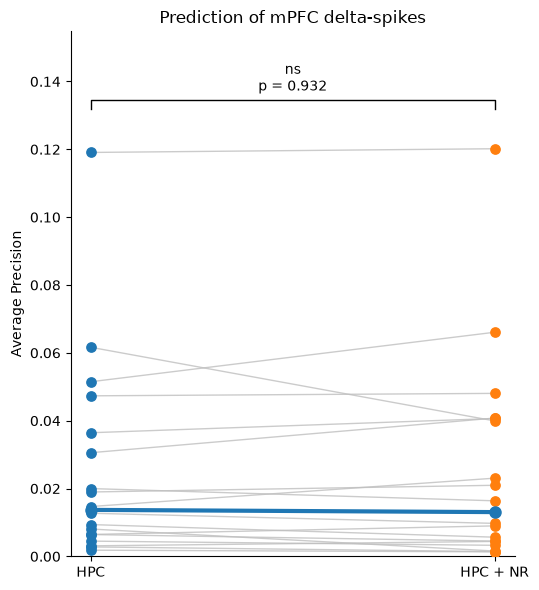

In [118]:
hpc = df_cnn["mean_AP"].values
hpc_nr = df_cnn_hpc_nr["mean_AP"].values

stat, p = wilcoxon(hpc, hpc_nr)

fig, ax = plt.subplots(figsize=(5.5, 6))

for i in range(len(hpc)):
    ax.plot(
        [0, 1],
        [hpc[i], hpc_nr[i]],
        color="0.75",
        linewidth=1,
        alpha=0.8
    )

ax.scatter(
    np.zeros(len(hpc)),
    hpc,
    s=45,
    zorder=3
)

ax.scatter(
    np.ones(len(hpc)),
    hpc_nr,
    s=45,
    zorder=3
)

med_hpc = np.median(hpc)
med_hpc_nr = np.median(hpc_nr)

ax.plot(
    [0, 1],
    [med_hpc, med_hpc_nr],
    linewidth=3,
    marker="o",
    markersize=8,
    zorder=4
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "HPC",
    "HPC + NR"
])

ax.set_ylabel("Average Precision")
ax.set_title("Prediction of mPFC delta-spikes")


y_max = max(hpc.max(), hpc_nr.max())
y_sig = y_max * 1.12

ax.plot(
    [0, 0, 1, 1],
    [y_sig*0.98, y_sig, y_sig, y_sig*0.98],
    color="black",
    linewidth=1
)

ax.text(
    0.5,
    y_sig * 1.01,
    f"ns\np = {p:.3f}",
    ha="center",
    va="bottom"
)

ax.set_ylim(
    0,
    y_sig * 1.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [119]:
n_shuffles = 100

shuffle_results_hpc_nr = []

for j, unit_id in enumerate(mpfc_units_ids):

    y = Y_mpfc[:, j].copy()
    real_ap = df_cnn_hpc_nr.loc[j, "mean_AP"]

    shuffled_AP = []

    print(f"\n{unit_id}")

    for s in range(n_shuffles):

        rng = np.random.default_rng(s)
        y_shuffle = rng.permutation(y)

        train_idx, val_idx = next(
            StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=s
            ).split(X_cnn_hpc_nr, y_shuffle)
        )

        tf.keras.backend.clear_session()

        model = build_cnn_hpc_nr()

        model.fit(
            X_cnn_hpc_nr[train_idx],
            y_shuffle[train_idx],
            epochs=30,
            batch_size=32,
            verbose=0
        )

        pred = model.predict(
            X_cnn_hpc_nr[val_idx],
            verbose=0
        ).ravel()

        ap = average_precision_score(
            y_shuffle[val_idx],
            pred
        )

        shuffled_AP.append(ap)

    p_value = (
        np.sum(np.array(shuffled_AP) >= real_ap) + 1
    ) / (n_shuffles + 1)

    shuffle_results_hpc_nr.append({
        "unit_id": unit_id,
        "real_AP": real_ap,
        "shuffle_AP": np.mean(shuffled_AP),
        "shuffle_std": np.std(shuffled_AP),
        "p_value": p_value
    })

    print(
        "réel =", round(real_ap, 4),
        "| shuffle =", round(np.mean(shuffled_AP), 4),
        "| p =", round(p_value, 4)
    )


df_shuffle_hpc_nr = pd.DataFrame(
    shuffle_results_hpc_nr
)

df_shuffle_hpc_nr


(10, np.int64(2))
réel = 0.0033 | shuffle = 0.0059 | p = 0.4455

(10, np.int64(5))
réel = 0.021 | shuffle = 0.0177 | p = 0.2277

(10, np.int64(24))
réel = 0.0481 | shuffle = 0.0483 | p = 0.4059

(10, np.int64(25))
réel = 0.0097 | shuffle = 0.017 | p = 0.7327

(11, np.int64(2))
réel = 0.1202 | shuffle = 0.0889 | p = 0.0495

(11, np.int64(11))
réel = 0.0231 | shuffle = 0.0135 | p = 0.1188

(11, np.int64(29))
réel = 0.0013 | shuffle = 0.0 | p = 0.0099

(11, np.int64(33))
réel = 0.0661 | shuffle = 0.029 | p = 0.0297

(11, np.int64(37))
réel = 0.009 | shuffle = 0.0114 | p = 0.2574

(11, np.int64(40))
réel = 0.0044 | shuffle = 0.0069 | p = 0.3663

(11, np.int64(43))
réel = 0.0408 | shuffle = 0.0145 | p = 0.0693

(11, np.int64(44))
réel = 0.0164 | shuffle = 0.0074 | p = 0.0891

(12, np.int64(8))
réel = 0.0057 | shuffle = 0.0134 | p = 0.6733

(12, np.int64(26))
réel = 0.0016 | shuffle = 0.0182 | p = 0.9505

(12, np.int64(33))
réel = 0.0014 | shuffle = 0.0 | p = 0.0099

(12, np.int64(37))
réel

,unit_id,real_AP,shuffle_AP,shuffle_std,p_value
0,"(10, 2)",0.003266,0.005892,0.014641,0.445545
1,"(10, 5)",0.020961,0.017727,0.023137,0.227723
2,"(10, 24)",0.048053,0.048294,0.014067,0.405941
3,"(10, 25)",0.009732,0.017027,0.015494,0.732673
4,"(11, 2)",0.120172,0.088936,0.014592,0.049505
5,"(11, 11)",0.023059,0.013513,0.022581,0.118812
6,"(11, 29)",0.001342,0.000000,0.000000,0.009901
7,"(11, 33)",0.066077,0.028968,0.011074,0.029703
8,"(11, 37)",0.008993,0.011420,0.021450,0.257426
9,"(11, 40)",0.004405,0.006907,0.015144,0.366337


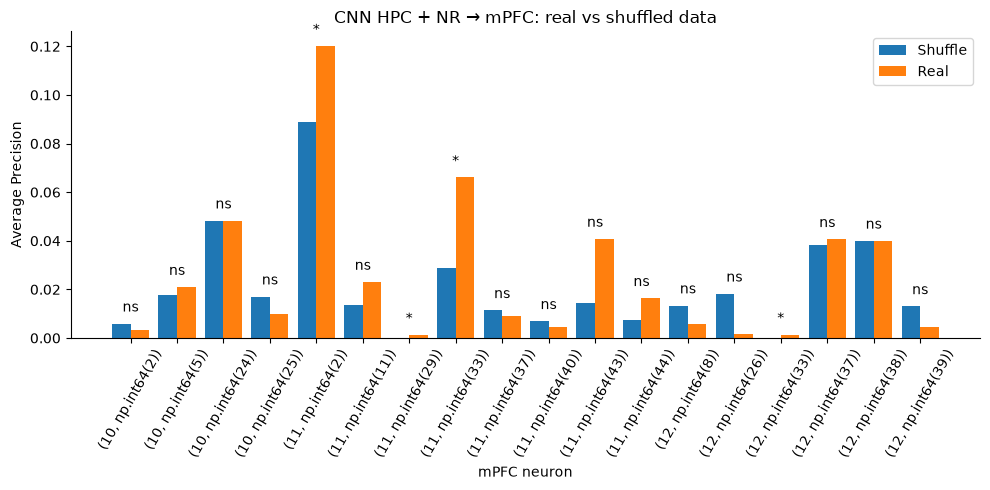

In [120]:
x = np.arange(len(df_shuffle_hpc_nr))

plt.figure(figsize=(10, 5))

plt.bar(
    x - 0.2,
    df_shuffle_hpc_nr["shuffle_AP"],
    width=0.4,
    label="Shuffle"
)

plt.bar(
    x + 0.2,
    df_shuffle_hpc_nr["real_AP"],
    width=0.4,
    label="Real"
)

for i, row in df_shuffle_hpc_nr.iterrows():

    y = max(row["real_AP"], row["shuffle_AP"])

    if row["p_value"] < 0.05:
        label = "*"
    else:
        label = "ns"

    plt.text(
        i,
        y + 0.005,
        label,
        ha="center"
    )

plt.xticks(
    x,
    df_shuffle_hpc_nr["unit_id"],
    rotation=60
)

plt.ylabel("Average Precision")
plt.xlabel("mPFC neuron")
plt.title("CNN HPC + NR → mPFC: real vs shuffled data")

plt.legend()

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [133]:
channels_nr = list(range(0, 64))
channels_hpc = list(range(96, 128))

channels = channels_nr + channels_hpc

print("NR :", len(channels_nr), "canaux")
print("HPC :", len(channels_hpc), "canaux")
print("Total :", len(channels), "canaux")

NR : 64 canaux
HPC : 32 canaux
Total : 96 canaux


In [134]:
selected_units = [
    (11, 2),
    (11, 33),
    (11, 43)
]

for unit in selected_units:

    j = mpfc_units_ids.index(unit)

    y = Y_mpfc[:, j]

    idx_pos = np.where(y == 1)[0]

    print(
        unit,
        "->",
        len(idx_pos),
        "delta-spikes"
    )

(11, 2) -> 270 delta-spikes
(11, 33) -> 75 delta-spikes
(11, 43) -> 18 delta-spikes


In [135]:
rng = np.random.default_rng(42)

datasets = {}

for unit in selected_units:

    j = mpfc_units_ids.index(unit)
    y = Y_mpfc[:, j]

    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]

    # même nombre de négatifs que de positifs
    idx_neg_selected = rng.choice(
        idx_neg,
        size=len(idx_pos),
        replace=False
    )

    idx_selected = np.concatenate([
        idx_pos,
        idx_neg_selected
    ])

    # labels correspondants
    y_selected = y[idx_selected]

    # delta peaks correspondants
    peaks_selected = delta_peaks[idx_selected]

    datasets[unit] = {
        "indices": idx_selected,
        "peaks": peaks_selected,
        "y": y_selected
    }

    print(
        unit,
        ":",
        len(idx_pos), "positifs +",
        len(idx_neg_selected), "négatifs =",
        len(idx_selected), "événements"
    )

(11, 2) : 270 positifs + 270 négatifs = 540 événements
(11, 33) : 75 positifs + 75 négatifs = 150 événements
(11, 43) : 18 positifs + 18 négatifs = 36 événements


In [136]:
window = np.array([-0.5, 0.5])

for unit in selected_units:

    peaks = datasets[unit]["peaks"]

    intervals = peaks[:, None] + window

    datasets[unit]["intervals"] = intervals

    print(
        unit,
        "->",
        intervals.shape
    )

(11, 2) -> (540, 2)
(11, 33) -> (150, 2)
(11, 43) -> (36, 2)


In [139]:
xml_file = next(chemin.glob("*.xml"))

In [ ]:
unit = (11, 2)

data_112, t_112 = fma.data.loadWideband(
    xml_file,
    channels=channels,
    intervals=datasets[unit]["intervals"],
    cat=False,
    trim=True
)

print(len(data_112))
print(data_112[0].shape)